**Activate User Environment**

In [1]:
import Pkg; Pkg.activate("/Users/heerakbanerjee/Documents/Newtrinos.jl/devenv/");
Pkg.instantiate();
Pkg.precompile();


  Activating project at `~/Documents/Newtrinos.jl/devenv`
Precompiling packages...
  21100.0 ms  ✓ Newtrinos
  1 dependency successfully precompiled in 25 seconds. 680 already precompiled.
  1 dependency had output during precompilation:
┌ Newtrinos
│  [ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xb871f44d5c61f46f, 0xc491a1fc15c5d2ec, 0x346b1797a0b4d4fb, 0xebcbe1597b23bbbb, 0x09c8f108c49881f0, 0x8227cf73732efbd2, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), ADTypes.NoAutoDiff())
│  [ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0xb871f44d5c61f46f, 0xc491a1fc15c5d2ec, 0x346b1797a0b4d4fb, 0xebcbe1597b23bbbb, 0x09c8f108c49881f0, 0x8227cf73732efbd2, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())
└  


In [2]:
Pkg.add("LaTeXStrings"); 

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/Documents/Newtrinos.jl/devenv/Project.toml`
    Manifest No packages added to or removed from `~/Documents/Newtrinos.jl/devenv/Manifest.toml`


**Load Packages**

In [3]:
#using Revise
using Newtrinos
using CairoMakie
#using Plots
using StatsBase
using LaTeXStrings
using Printf

In [12]:

# Configure both experiments
#coherent_csi = Newtrinos.coherent_csi.configure()
#coherent_lAr = Newtrinos.coherent_lAr.configure()

#csi_assets = coherent_csi.assets
#lAr_assets = coherent_lAr.assets


function plot_ffsq_vs_er(asset_args...; n_sigma=1.0, n_rn=41, max_panels=3, savePlots=true)
    assets_list =
        length(asset_args) == 1 && asset_args[1] isa AbstractVector ? collect(asset_args[1]) : collect(asset_args)

    panel_specs = Tuple{Any, Any}[]
    for assets in assets_list
        for iso in assets.isotopes
            push!(panel_specs, (assets, iso))
        end
    end

    n_panels = min(length(panel_specs), max_panels)
    n_panels == 0 && error("No isotopes found in the provided assets.")

    iso_names = Dict(
        :Rn_Cs => L"$^{133}\mathrm{Cs}: \mathrm{R}_{\mathrm{wk}} = $",
        :Rn_I  => L"$^{127}\mathrm{I}: \mathrm{R}_{\mathrm{wk}} = $",
        :Rn_Ar => L"$^{40}\mathrm{Ar}: \mathrm{R}_{\mathrm{wk}} = $",
    )

    models = [
        (:helm, "Helm", :royalblue),
        (:klein_nystrand, "Klein-Nystrand", :darkorange),
        (:sym_fermi, "Sym. Fermi", :seagreen),
    ]

    fig = Figure(size=(420 * n_panels, 420))
    axes = Axis[]

    for col in 1:n_panels
        assets, iso = panel_specs[col]

        er = assets.er_centers .* 1e-3
        x_keV = er .* 1e3

        mn = iso.mass
        rn0 = iso.Rn_nom
        sigma_rn = 0.05 * rn0
        rn_grid = range(rn0 - n_sigma * sigma_rn, rn0 + n_sigma * sigma_rn, length=n_rn)

        ax = Axis(
            fig[1, col],
            xscale=log10,
            yscale=log10,
            xlabel="Nuclear Recoil Energy (keV)",
            ylabel=(col == 1 ? L"$\mathbf{|F_W(q^2)|^2}$" : ""),
            title=latexstring(iso_names[iso.Rn_key] * @sprintf("%.2f", rn0) * L"\mathrm{fm}\pm 5\%"),
        )
        push!(axes, ax)

        for (model_sym, model_label, model_color) in models
            y_center = [Newtrinos.cevns_xsec.ffsq(e, mn, rn0; model=model_sym) for e in er]
            y_by_rn = [[Newtrinos.cevns_xsec.ffsq(e, mn, rn; model=model_sym) for e in er] for rn in rn_grid]
            y_mat = reduce(hcat, y_by_rn)
            y_lo = vec(minimum(y_mat, dims=2))
            y_hi = vec(maximum(y_mat, dims=2))

            band!(ax, x_keV, y_lo, y_hi, color=(model_color, 0.22))
            lines!(ax, x_keV, y_center, color=model_color, linewidth=2, label=model_label)
        end
    end

    axislegend(axes[end]; position=:lb, framevisible=false)

    if savePlots
        save("coherent_postPred/ffsq_vs_er.png", fig)
        save("coherent_postPred/ffsq_vs_er.pdf", fig)
    end
    display(fig)
end


#

plot_ffsq_vs_er (generic function with 1 method)

In [22]:
sqrt(3/5*5.7^2 + 3*0.9^2)
sqrt(3/5*5.7^2 + 6*0.7^2)
sqrt(3/5*4.1^2 + 6*0.7^2)
#sqrt(3/5*4.1^2 + 3*0.9^2)

3.6091550257643408

In [24]:
(0.022/3.457)*100

0.6363899334683251

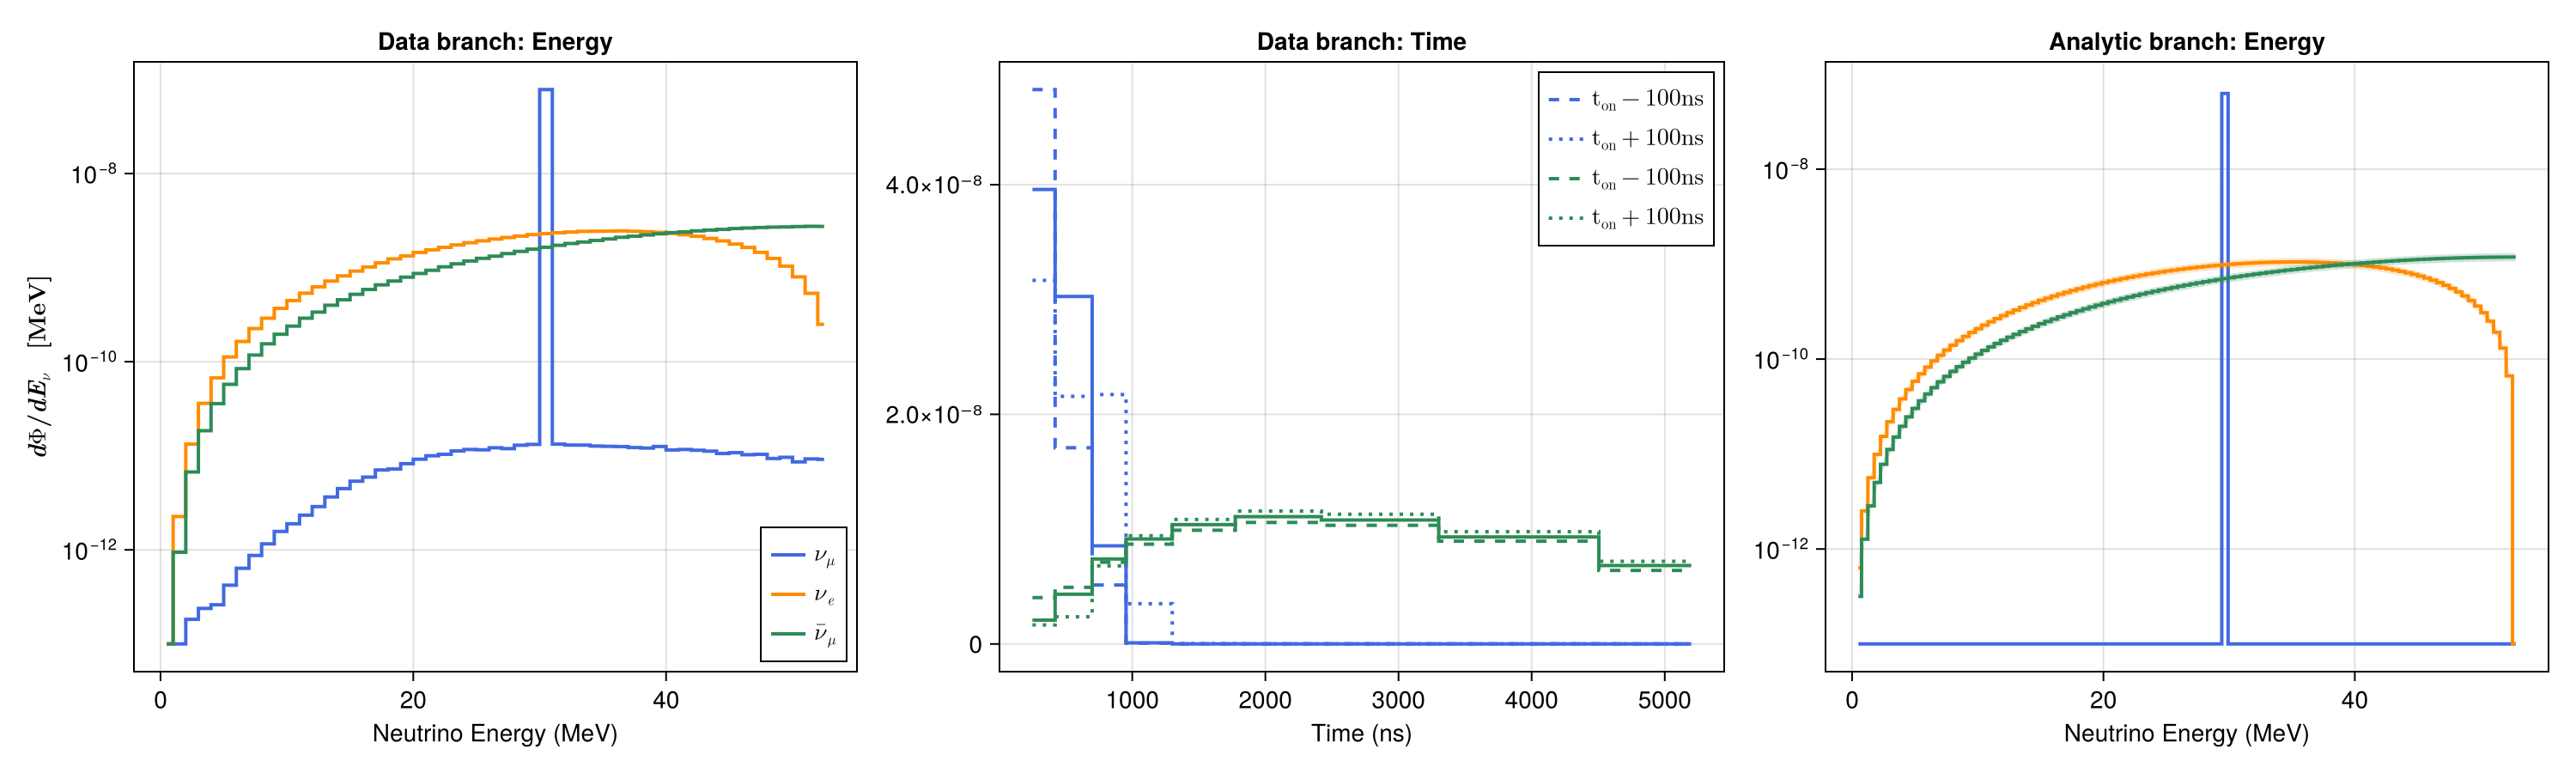

In [19]:
# SNS flux projections with 1σ nuisance variations (CairoMakie)
sns_flux_data = Newtrinos.sns_flux.configure(exposure=1.0, distance=1000.0, use_data=true)
sns_flux_analytic = Newtrinos.sns_flux.configure(exposure=1.0, distance=1000.0, use_data=false)

positive_floor(v) = begin
    positive = filter(x -> x > 0, v)
    floor = isempty(positive) ? 1e-300 : 1e-13
    max.(v, floor)
end
project_energy(flux_matrix) = sum(flux_matrix, dims=2)[:, 1]
project_time(flux_matrix) = sum(flux_matrix, dims=1)[1, :]
midpoints(edges) = (edges[1:end-1] .+ edges[2:end]) ./ 2

colors = Dict(:flux_mu => :royalblue, :flux_e => :darkorange, :flux_mu_bar => :seagreen)
labels = Dict(:flux_mu => L"\nu_\mu", :flux_e => L"\nu_e", :flux_mu_bar => L"\bar{\nu}_\mu")

# Central fluxes
flux_data_central = sns_flux_data.flux(sns_flux_data.params)
flux_analytic_central = sns_flux_analytic.flux(sns_flux_analytic.params)

# 1σ variations split by projection as requested
params_data = sns_flux_data.params

# Energy projection band: vary flux_norm only (flux_onset fixed)
flux_norm_sigma = 0.1
params_data_flux_norm_variations = (
    (flux_norm = params_data.flux_norm - flux_norm_sigma*params_data.flux_norm, flux_onset = params_data.flux_onset),
    (flux_norm = params_data.flux_norm + flux_norm_sigma*params_data.flux_norm, flux_onset = params_data.flux_onset),
)
flux_data_flux_norm_varied = [sns_flux_data.flux(p) for p in params_data_flux_norm_variations]

# Time projection band: vary flux_onset only (flux_norm fixed)
flux_onset_sigma = 100.0
params_data_flux_onset_variations = (
    (flux_norm = params_data.flux_norm, flux_onset = params_data.flux_onset - flux_onset_sigma),
    (flux_norm = params_data.flux_norm, flux_onset = params_data.flux_onset + flux_onset_sigma),
)
flux_data_flux_onset_varied = [sns_flux_data.flux(p) for p in params_data_flux_onset_variations]

# Analytic branch: one varied parameter
params_analytic = sns_flux_analytic.params
sns_nu_per_POT_sigma = 0.009
params_analytic_variations = (
    (sns_nu_per_POT = params_analytic.sns_nu_per_POT - sns_nu_per_POT_sigma,),
    (sns_nu_per_POT = params_analytic.sns_nu_per_POT + sns_nu_per_POT_sigma,),
)
flux_analytic_varied = [sns_flux_analytic.flux(p) for p in params_analytic_variations]

energy_centers = flux_data_central.E
time_centers = midpoints(flux_data_central.T)

function envelope_from_variations(series_list)
    mat = reduce(hcat, series_list)
    return vec(minimum(mat, dims=2)), vec(maximum(mat, dims=2))
end

fig = Figure(size=(1500, 450))

ylabelstring = L"$\mathbf{{d\Phi}/{dE_\nu}\quad[\mathrm{MeV}]}$"

ax1 = Axis(
    fig[1, 1],
    yscale=log10,
    xlabel="Neutrino Energy (MeV)",
    ylabel=ylabelstring,
    title="Data branch: Energy",
)

ax2 = Axis(
    fig[1, 2],
    xlabel="Time (ns)",
    title="Data branch: Time",
)

ax3 = Axis(
    fig[1, 3],
    yscale=log10,
    xlabel="Neutrino Energy (MeV)",
    title="Analytic branch: Energy",
)

for flavor in (:flux_mu, :flux_e, :flux_mu_bar)
    # Data branch central curves
    y_data_energy = positive_floor(project_energy(getproperty(flux_data_central, flavor)))
    y_data_time = positive_floor(project_time(getproperty(flux_data_central, flavor)))

    # Data energy envelope: flux_norm-only variation
    y_data_energy_var = [positive_floor(project_energy(getproperty(f, flavor))) for f in flux_data_flux_norm_varied]
    y_data_energy_lo, y_data_energy_hi = envelope_from_variations(y_data_energy_var)

    # Data time envelope: flux_onset-only variation
    y_data_time_var = [positive_floor(project_time(getproperty(f, flavor))) for f in flux_data_flux_onset_varied]
    y_data_time_lo, y_data_time_hi = envelope_from_variations(y_data_time_var)

    band!(ax1, energy_centers, y_data_energy_lo, y_data_energy_hi; color=(colors[flavor], 0.22))
    stairs!(ax1, energy_centers, y_data_energy; step=:center, label=labels[flavor], color=colors[flavor], linewidth=2)
    if flavor != :flux_e
        #band!(ax2, time_centers, y_data_time_lo, y_data_time_hi; color=(colors[flavor], 0.22))
        stairs!(ax2, time_centers, y_data_time_var[1]; step=:center, label=L"${\mathrm{t}}_{\mathrm{on}} - 100\mathrm{ns}$", color=colors[flavor], linewidth=2, linestyle=:dash)
        stairs!(ax2, time_centers, y_data_time; step=:center, label=nothing, color=colors[flavor], linewidth=2)
        stairs!(ax2, time_centers, y_data_time_var[2]; step=:center, label=L"${\mathrm{t}}_{\mathrm{on}} + 100\mathrm{ns}$", color=colors[flavor], linewidth=2, linestyle=:dot)
    end
    #crossbar!(ax2, time_centers, y_data_time, y_data_time_lo, y_data_time_hi, strokecolor=(colors[flavor], 1.0), strokewidth=2)

    # Analytic branch central curve and envelope
    y_analytic = positive_floor(getproperty(flux_analytic_central, flavor))
    y_analytic_var = [positive_floor(getproperty(f, flavor)) for f in flux_analytic_varied]
    y_analytic_lo, y_analytic_hi = envelope_from_variations(y_analytic_var)

    band!(ax3, flux_analytic_central.E, y_analytic_lo, y_analytic_hi; color=(colors[flavor], 0.22))
    stairs!(ax3, flux_analytic_central.E, y_analytic; step=:center, label=nothing, color=colors[flavor], linewidth=2)
end

axislegend(ax1; position=:rb)
axislegend(ax2; position=:rt)
save("coherent_postPred/flux_envelope.png", fig)
save("coherent_postPred/flux_envelope.pdf", fig)
fig

In [4]:
sns_flux_data.params

(flux_norm = 1.0, flux_onset = 0.0)

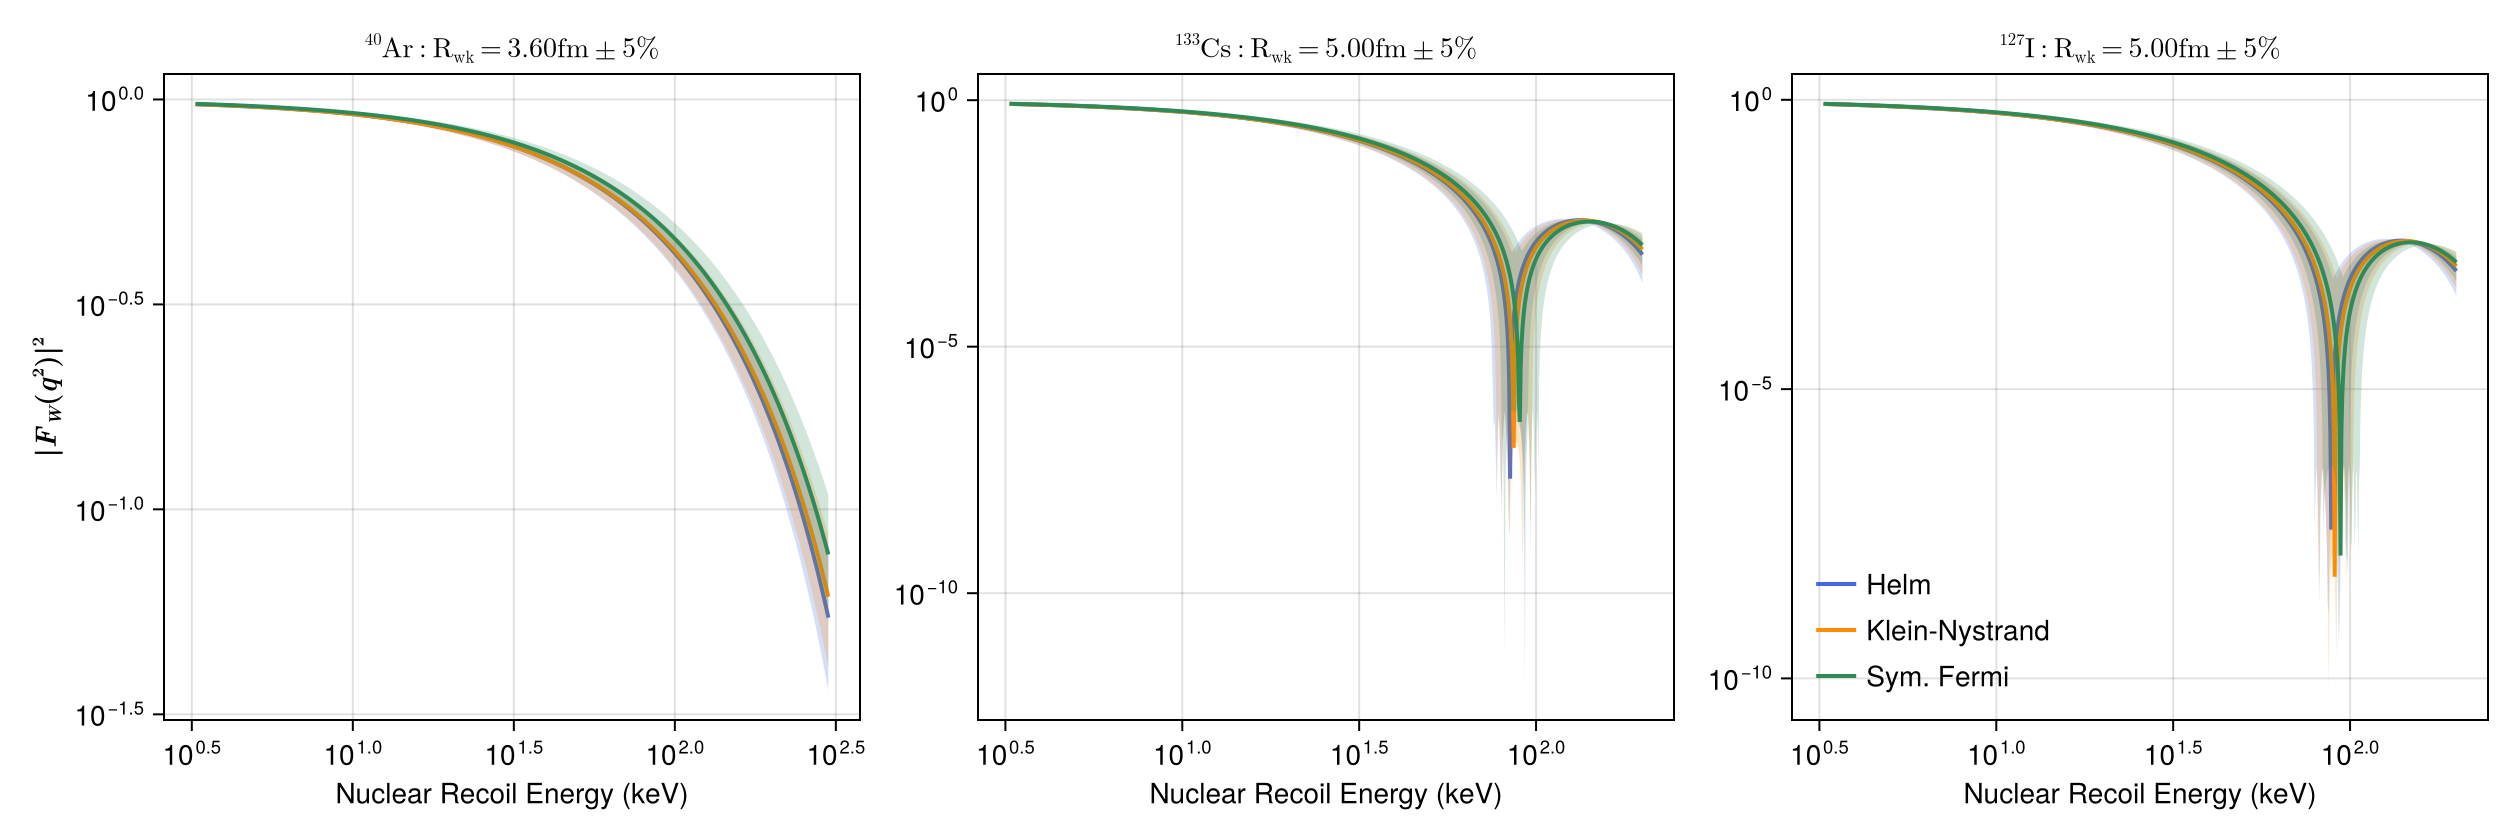

CairoMakie.Screen{IMAGE}


In [14]:
# Configure both experiments
#coherent_csi = Newtrinos.coherent_csi.configure()
#coherent_lAr = Newtrinos.coherent_lAr.configure()
plot_ffsq_vs_er(coherent_lAr.assets, coherent_csi.assets; n_sigma=1.0, savePlots=true)

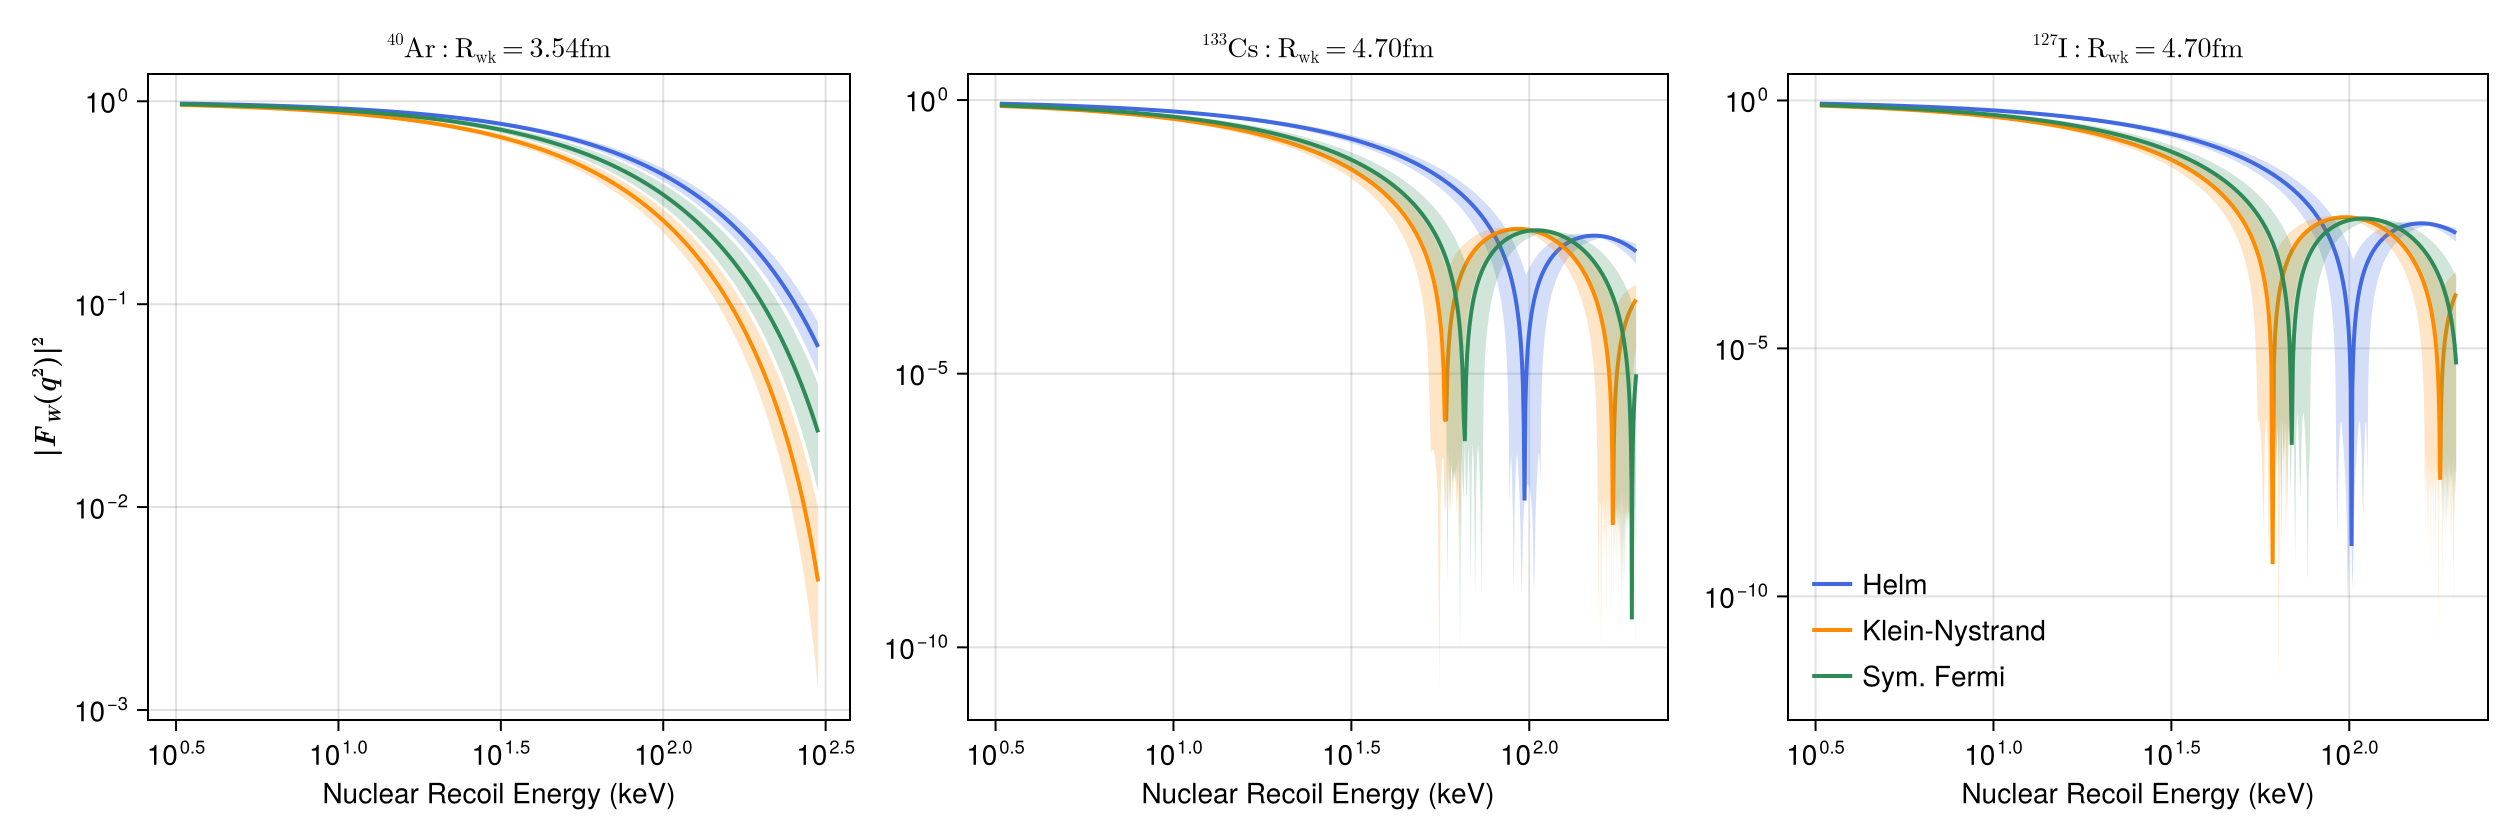

CairoMakie.Screen{IMAGE}


In [14]:
plot_ffsq_vs_er(coherent_lAr.assets, coherent_csi.assets; n_sigma=1.0)

**Test CsI Dataset and Prediction**

[ Info: Flux is not fully configured yet.
[ Info: Loading and binning CsI data


Total signal counts: 364.685832600782

[ Info: Configuring Flux
[ Info: Configuring CEvNS cross-section assets
[ Info: Configured COHERENT CsI module.



Total BRN background counts: 27.40637754948838
Total NIN counts: 6.900994323180432
Total SS background counts: 3889.0
Total observed counts: 4170


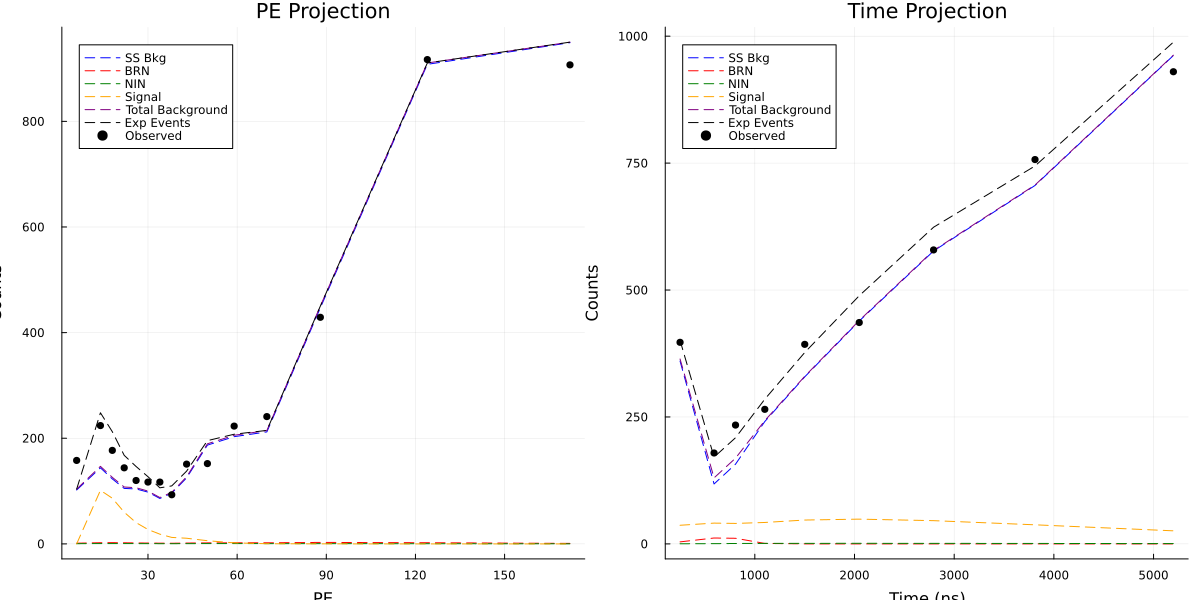

In [18]:
using Plots
# Configure the COHERENT_CSI experiment
coherent_csi = Newtrinos.coherent_csi.configure()

# Access the configured components
physics = coherent_csi.physics
params = Newtrinos.get_params(coherent_csi)
assets = coherent_csi.assets

# Compute the expected signal and backgrounds
signal = Newtrinos.coherent_csi.get_expected(params, physics, assets)  # (n_out, n_time)
#@info "Computed expected signal."
brn, nin, ssBkg = Newtrinos.coherent_csi.get_backgrounds(params, assets)  # (n_out, n_time)
total_bkg = brn .+ nin .+ ssBkg  # (n_out, n_time)
#@info "Computed expected backgrounds."
exp_events = signal .+ total_bkg  # (n_out, n_time)
#@info "Computed expected total events."
# Observed data
observed = assets.observed  # (n_out, n_time)

# Compute projections
PE_bins = assets.out_centers
time_bins = assets.time_bins

# PE projection: sum over time bins
signal_PE = sum(signal, dims=2)[:, 1]
brn_PE = sum(brn, dims=2)[:, 1]
nin_PE = sum(nin, dims=2)[:, 1]
ssBkg_PE = sum(ssBkg, dims=2)[:, 1]
total_bkg_PE = sum(total_bkg, dims=2)[:, 1]
exp_events_PE = sum(exp_events, dims=2)[:, 1]
observed_PE = sum(observed, dims=2)[:, 1]

# Time projection: sum over PE bins
signal_time = sum(signal, dims=1)[1, :]
brn_time = sum(brn, dims=1)[1, :]
nin_time = sum(nin, dims=1)[1, :]
ssBkg_time = sum(ssBkg, dims=1)[1, :]
total_bkg_time = sum(total_bkg, dims=1)[1, :]
exp_events_time = sum(exp_events, dims=1)[1, :]
observed_time = sum(observed, dims=1)[1, :]

# Print total counts
println("Total signal counts: ", sum(signal))
println("Total BRN background counts: ", sum(brn))
println("Total NIN counts: ", sum(nin))
println("Total SS background counts: ", sum(ssBkg))
println("Total observed counts: ", sum(observed))

# Create the (1, 2) subplot layout
plot1 = Plots.plot(PE_bins, ssBkg_PE; label="SS Bkg", linestyle=:dash, color=:blue, xlabel="PE", ylabel="Counts", title="PE Projection")
Plots.plot!(PE_bins, brn_PE; label="BRN", linestyle=:dash, color=:red)
Plots.plot!(PE_bins, nin_PE; label="NIN", linestyle=:dash, color=:green)
Plots.plot!(PE_bins, signal_PE; label="Signal", linestyle=:dash, color=:orange)
Plots.plot!(PE_bins, total_bkg_PE; label="Total Background", linestyle=:dash, color=:purple)
Plots.plot!(PE_bins, exp_events_PE; label="Exp Events", linestyle=:dash, color=:black)
Plots.scatter!(PE_bins, observed_PE; label="Observed", color=:black)

plot2 = Plots.plot(time_bins, ssBkg_time; label="SS Bkg", linestyle=:dash, color=:blue, xlabel="Time (ns)", ylabel="Counts", title="Time Projection")
Plots.plot!(time_bins, brn_time; label="BRN", linestyle=:dash, color=:red)
Plots.plot!(time_bins, nin_time; label="NIN", linestyle=:dash, color=:green)
Plots.plot!(time_bins, signal_time; label="Signal", linestyle=:dash, color=:orange)
Plots.plot!(time_bins, total_bkg_time; label="Total Background", linestyle=:dash, color=:purple)
Plots.plot!(time_bins, exp_events_time; label="Exp Events", linestyle=:dash, color=:black)
Plots.scatter!(time_bins, observed_time; label="Observed", color=:black)

# Combine the two plots into a single layout
Plots.plot(plot1, plot2, layout=(1, 2), size=(1200, 600))

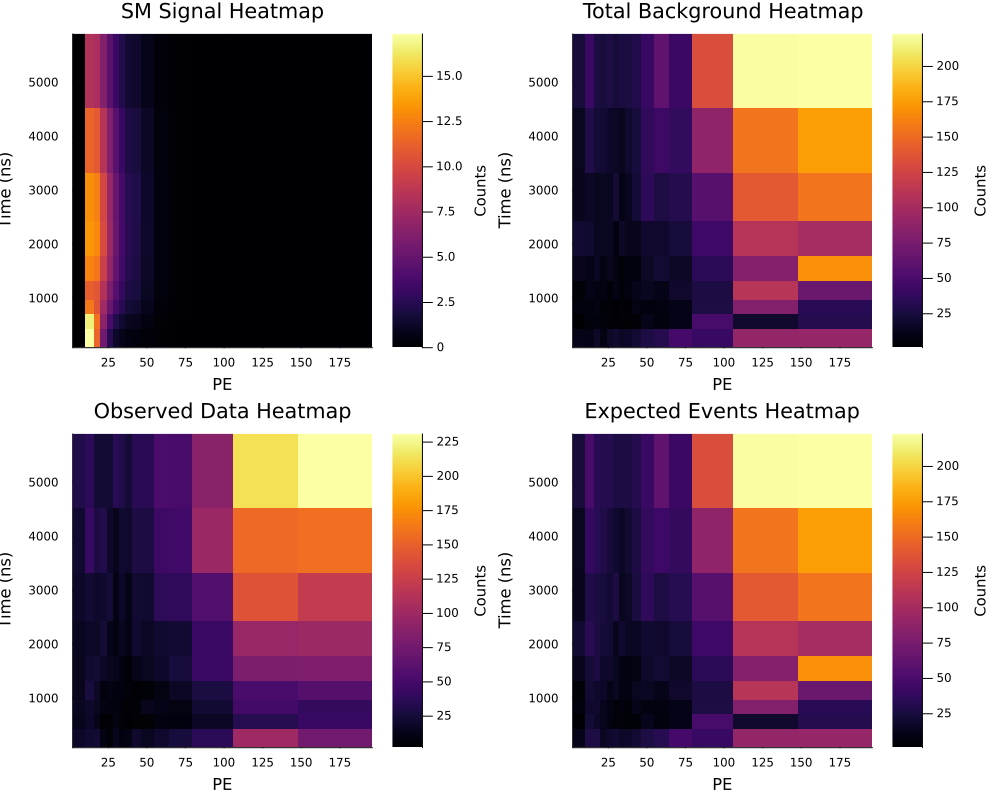

In [14]:
p1= Plots.heatmap(PE_bins, time_bins, signal'; xlabel="PE", ylabel="Time (ns)", title="SM Signal Heatmap", colorbar_title="Counts")
p2= Plots.heatmap(PE_bins, time_bins, total_bkg'; xlabel="PE", ylabel="Time (ns)", title="Total Background Heatmap", colorbar_title="Counts")
p3= Plots.heatmap(PE_bins, time_bins, observed'; xlabel="PE", ylabel="Time (ns)", title="Observed Data Heatmap", colorbar_title="Counts")
p4= Plots.heatmap(PE_bins, time_bins, exp_events'; xlabel="PE", ylabel="Time (ns)", title="Expected Events Heatmap", colorbar_title="Counts")

Plots.plot(p1, p2, p3, p4, layout=(2, 2), size=(1000, 800))

**Test l-Ar Dataset and Prediction**

Total signal counts: 125.8866403391622

[ Info: Loading coherent lAr data
[ Info: Configuring CEvNS cross-section assets



Total BRN background counts: 496.99999307
Total Delayed BRN background counts: 33.00001642
Total SS background counts: 3152.0001600000032
Total observed counts: 3752


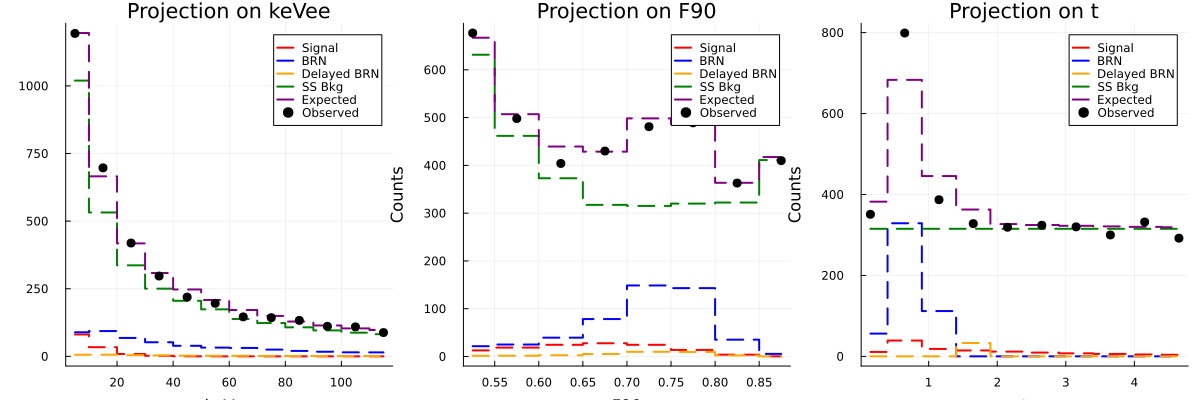

In [19]:
# Configure the COHERENT_lAr experiment
coherent_lAr = Newtrinos.coherent_lAr.configure()

# Access the configured components
physics = coherent_lAr.physics
params = Newtrinos.get_params(coherent_lAr)
assets = coherent_lAr.assets

# Signal and Backgrounds
expected_counts = Newtrinos.coherent_lAr.get_expected(params, physics, assets)
bkg_brn, bkg_delbrn, bkg_ss_bkg = Newtrinos.coherent_lAr.get_backgrounds(params, assets)
total_bkg = bkg_brn .+ bkg_delbrn .+ bkg_ss_bkg
# Cumulative expected signal + backgrounds
signal_cum = bkg_brn .+ bkg_delbrn .+ bkg_ss_bkg .+ expected_counts

# Observed data
observed_counts = assets.observed

# Define the second subplot matrix: Projections on keVee, F90, and t
# Projections are computed by summing over the appropriate bins
keVee_centers = assets.out_centers
f90_centers = assets.f90_centers
timing_centers = assets.timing_centers

# Reshape the signal and background arrays to match the binning structure
n_keVee_bins = length(keVee_centers)
n_f90_bins = length(f90_centers)
n_timing_bins = length(timing_centers)
# Print total counts
println("Total signal counts: ", sum(expected_counts))
println("Total BRN background counts: ", sum(bkg_brn))
println("Total Delayed BRN background counts: ", sum(bkg_delbrn))
println("Total SS background counts: ", sum(bkg_ss_bkg))
println("Total observed counts: ", sum(observed_counts))

# Stack the bin centers and counts into separate arrays for each component
data_signal = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                   repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                   repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                   expected_counts)

data_expected = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                      repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                      repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                      signal_cum)

data_brn = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                bkg_brn)

data_delbrn = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                   repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                   repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                   bkg_delbrn)

data_ss_bkg = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                   repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                   repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                   bkg_ss_bkg)

data_observed = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                     repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                     repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                     observed_counts)

# Function to compute projections
function compute_projection(data, bin_centers, col_index)
    proj = zeros(length(bin_centers))
    for i in 1:length(bin_centers)
        proj[i] = sum(data[data[:, col_index] .== bin_centers[i], 4])
    end
    return proj
end

# Compute projections for each component
proj_keVee_signal = compute_projection(data_signal, keVee_centers, 1)
proj_keVee_brn = compute_projection(data_brn, keVee_centers, 1)
proj_keVee_delbrn = compute_projection(data_delbrn, keVee_centers, 1)
proj_keVee_ss_bkg = compute_projection(data_ss_bkg, keVee_centers, 1)
proj_keVee_observed = compute_projection(data_observed, keVee_centers, 1)
proj_keVee_expected = compute_projection(data_expected, keVee_centers, 1)

proj_F90_signal = compute_projection(data_signal, f90_centers, 2)
proj_F90_brn = compute_projection(data_brn, f90_centers, 2)
proj_F90_delbrn = compute_projection(data_delbrn, f90_centers, 2)
proj_F90_ss_bkg = compute_projection(data_ss_bkg, f90_centers, 2)
proj_F90_observed = compute_projection(data_observed, f90_centers, 2)
proj_F90_expected = compute_projection(data_expected, f90_centers, 2)

proj_t_signal = compute_projection(data_signal, timing_centers, 3)
proj_t_brn = compute_projection(data_brn, timing_centers, 3)
proj_t_delbrn = compute_projection(data_delbrn, timing_centers, 3)
proj_t_ss_bkg = compute_projection(data_ss_bkg, timing_centers, 3)
proj_t_observed = compute_projection(data_observed, timing_centers, 3)
proj_t_expected = compute_projection(data_expected, timing_centers, 3)

# Plot the projections with step-like visualization
plt4 = Plots.plot(keVee_centers, proj_keVee_signal, label="Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash, xlabel="keVee", ylabel="Counts", title="Projection on keVee")
Plots.plot!(plt4, keVee_centers, proj_keVee_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
Plots.plot!(plt4, keVee_centers, proj_keVee_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
Plots.plot!(plt4, keVee_centers, proj_keVee_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
Plots.plot!(plt4, keVee_centers, proj_keVee_expected, label="Expected", seriestype=:stepmid, color=:purple, lw=2, linestyle=:dash)
Plots.plot!(plt4, keVee_centers, proj_keVee_observed, label="Observed", seriestype=:scatter, marker=:circle, markersize=5, color=:black)

plt5 = Plots.plot(f90_centers, proj_F90_signal, label="Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash, xlabel="F90", ylabel="Counts", title="Projection on F90")
Plots.plot!(plt5, f90_centers, proj_F90_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
Plots.plot!(plt5, f90_centers, proj_F90_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
Plots.plot!(plt5, f90_centers, proj_F90_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
Plots.plot!(plt5, f90_centers, proj_F90_expected, label="Expected", seriestype=:stepmid, color=:purple, lw=2, linestyle=:dash)
Plots.plot!(plt5, f90_centers, proj_F90_observed, label="Observed", seriestype=:scatter, marker=:circle, markersize=5, color=:black)

plt6 = Plots.plot(timing_centers, proj_t_signal, label="Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash, xlabel="t", ylabel="Counts", title="Projection on t")
Plots.plot!(plt6, timing_centers, proj_t_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
Plots.plot!(plt6, timing_centers, proj_t_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
Plots.plot!(plt6, timing_centers, proj_t_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
Plots.plot!(plt6, timing_centers, proj_t_expected, label="Expected", seriestype=:stepmid, color=:purple, lw=2, linestyle=:dash)
Plots.plot!(plt6, timing_centers, proj_t_observed, label="Observed", seriestype=:scatter, marker=:circle, markersize=5, color=:black)

# Combine the plots into a single layout
Plots.plot(plt4, plt5, plt6, layout=(1,3), size=(1200,400))
display(current())

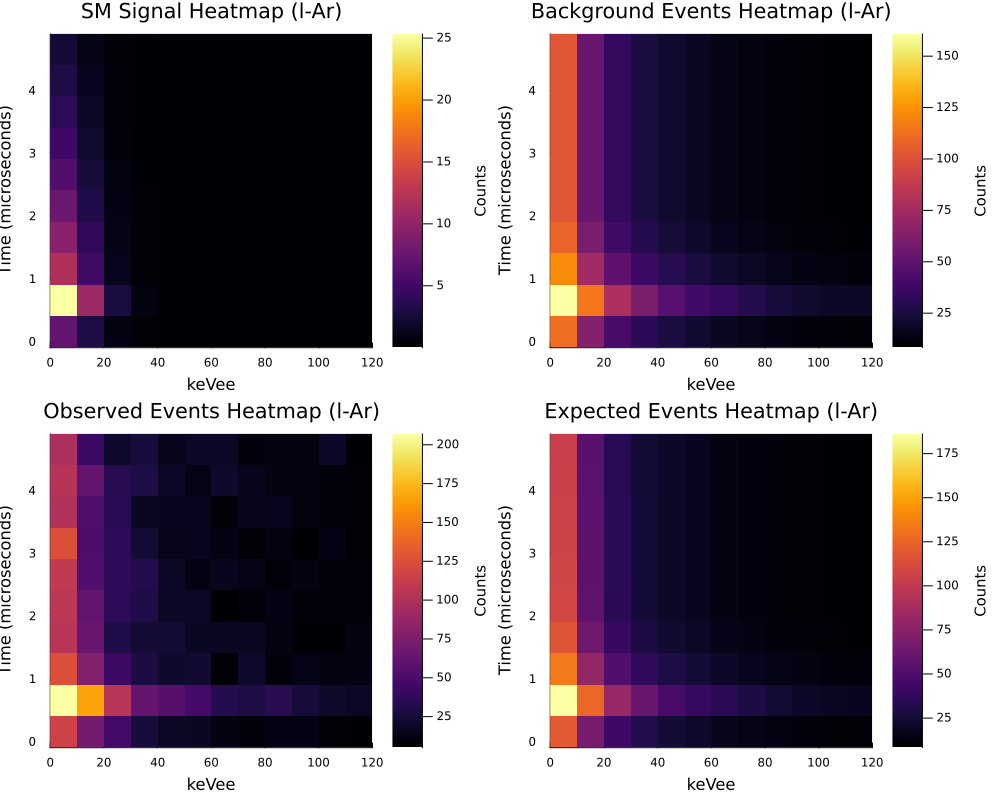

In [ ]:
# Reshape expected_counts to (keVee, F90, time)
expected_reshaped = permutedims(
    reshape(signal_cum, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
)
observed_reshaped = permutedims(
    reshape(observed_counts, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
)
signal_reshaped = permutedims(
    reshape(expected_counts, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
)
bkg_reshaped = permutedims(
    reshape(total_bkg, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
)

# Sum over F90 to get (keVee, time) matrix
signal_keVee_time = sum(signal_reshaped, dims=2)[:, 1, :]
observed_keVee_time = sum(observed_reshaped, dims=2)[:, 1, :]
expected_keVee_time = sum(expected_reshaped, dims=2)[:, 1, :]
bkg_keVee_time = sum(bkg_reshaped, dims=2)[:, 1, :]

# Plot heatmap: X=keVee, Y=time

p1 = Plots.heatmap(
    keVee_centers,
    timing_centers,
    observed_keVee_time',
    xlabel="keVee",
    ylabel="Time (microseconds)",
    title="Observed Events Heatmap (l-Ar)",
    colorbar_title="Counts"
)

p2= Plots.heatmap(
    keVee_centers,
    timing_centers,
    expected_keVee_time',
    xlabel="keVee",
    ylabel="Time (microseconds)",
    title="Expected Events Heatmap (l-Ar)",
    colorbar_title="Counts"
)

p3= Plots.heatmap(
    keVee_centers,
    timing_centers,
    signal_keVee_time',
    xlabel="keVee",
    ylabel="Time (microseconds)",
    title="SM Signal Heatmap (l-Ar)",
    colorbar_title="Counts"
)

p4= Plots.heatmap(
    keVee_centers,
    timing_centers,
    bkg_keVee_time',
    xlabel="keVee",
    ylabel="Time (microseconds)",
    title="Background Events Heatmap (l-Ar)",
    colorbar_title="Counts"
)

Plots.plot(p3, p4, p1, p2, layout=(2,2), size=(1000,800))

display(current())

**Check Parameter Dependence**

*CsI Detector*

[ Info: Configuring CEvNS cross-section assets


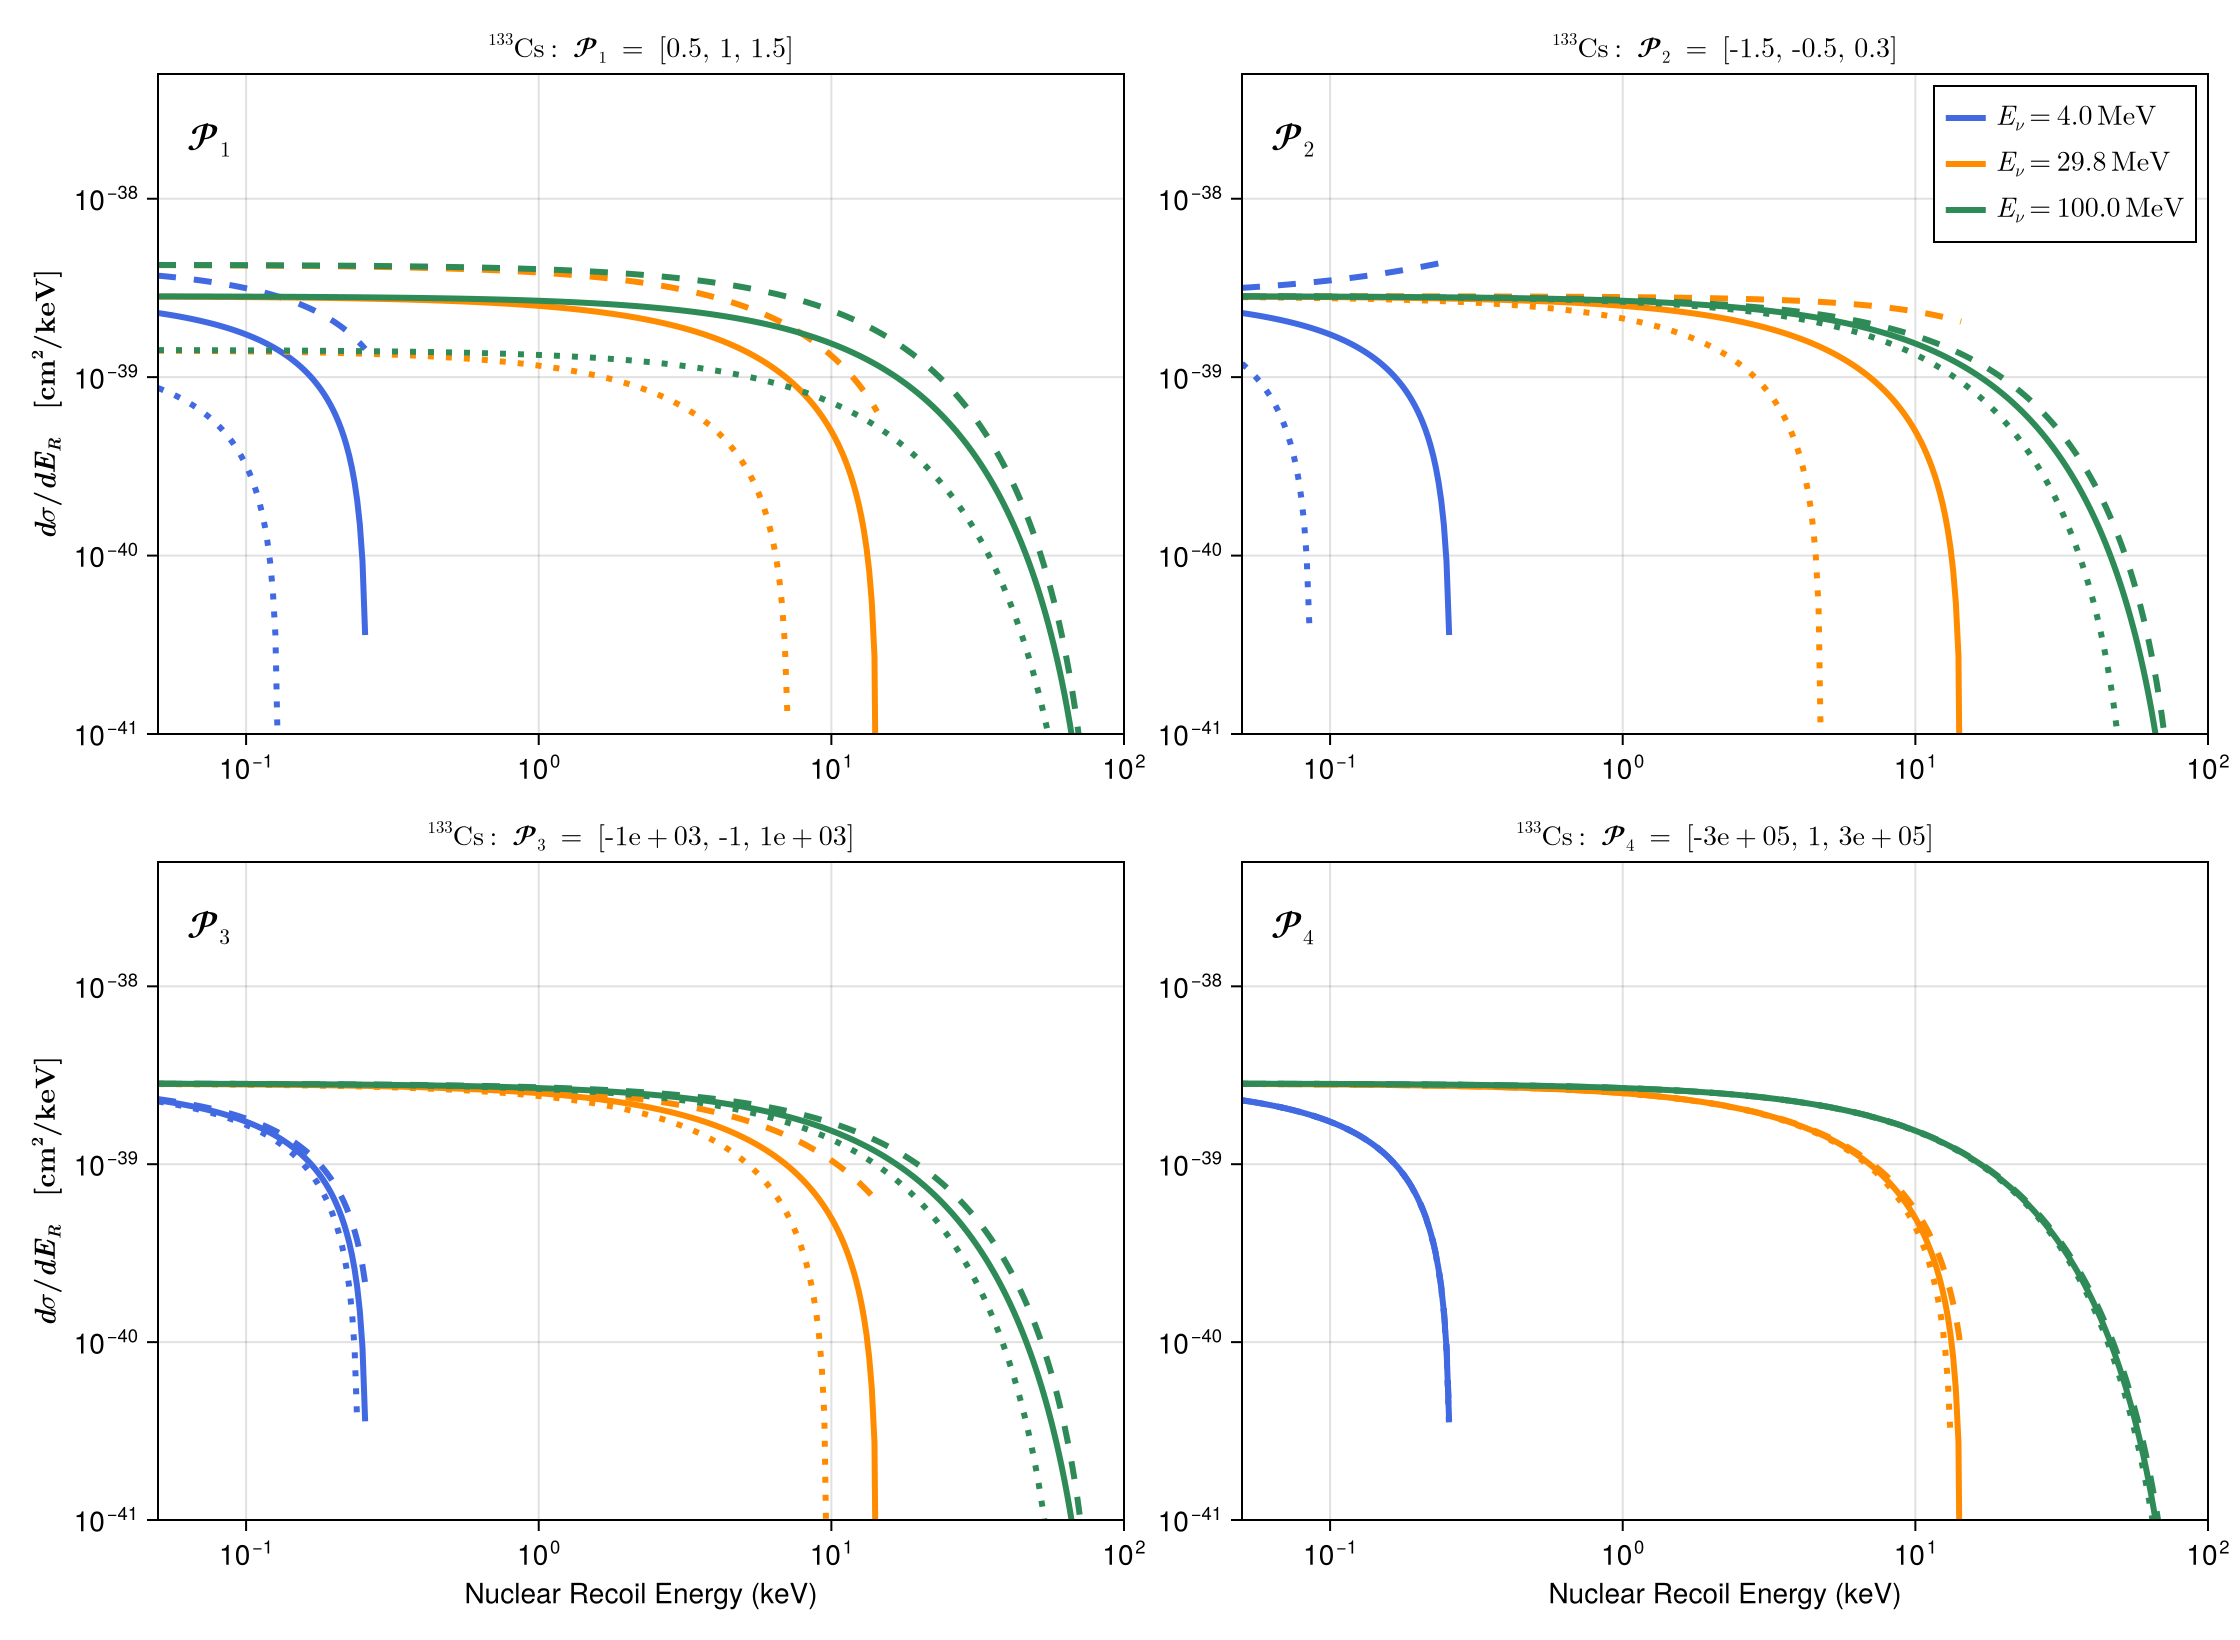

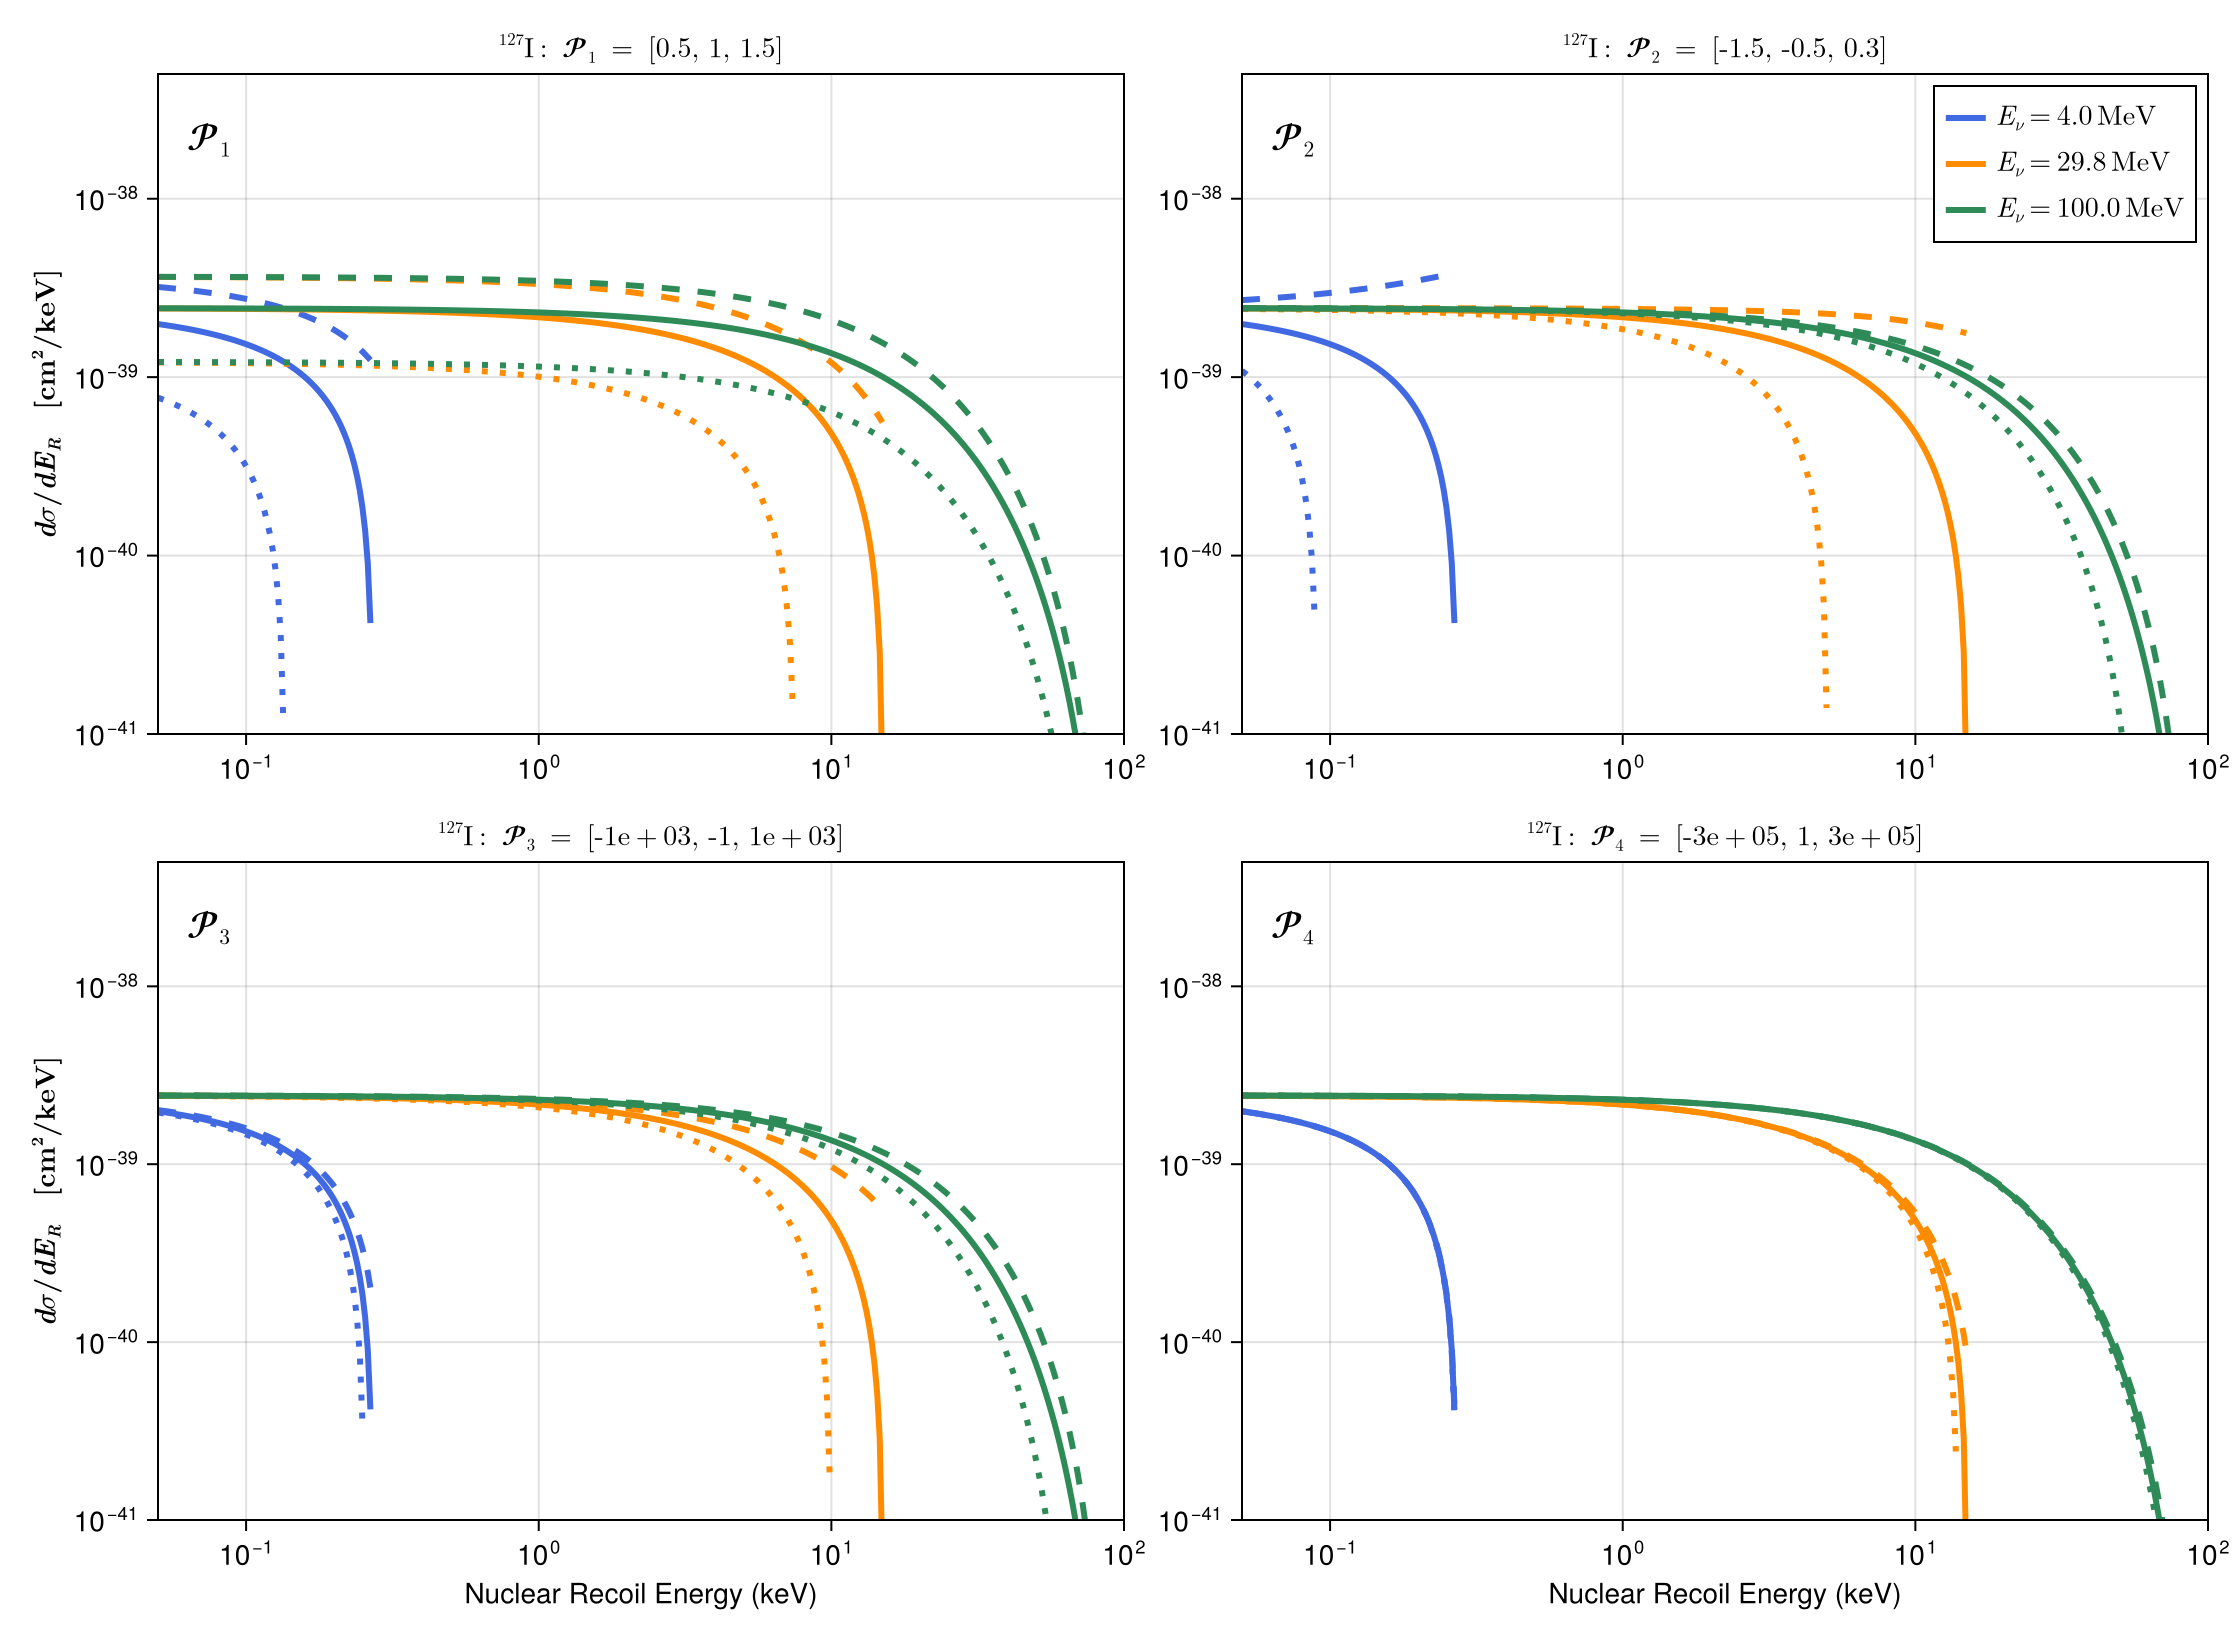

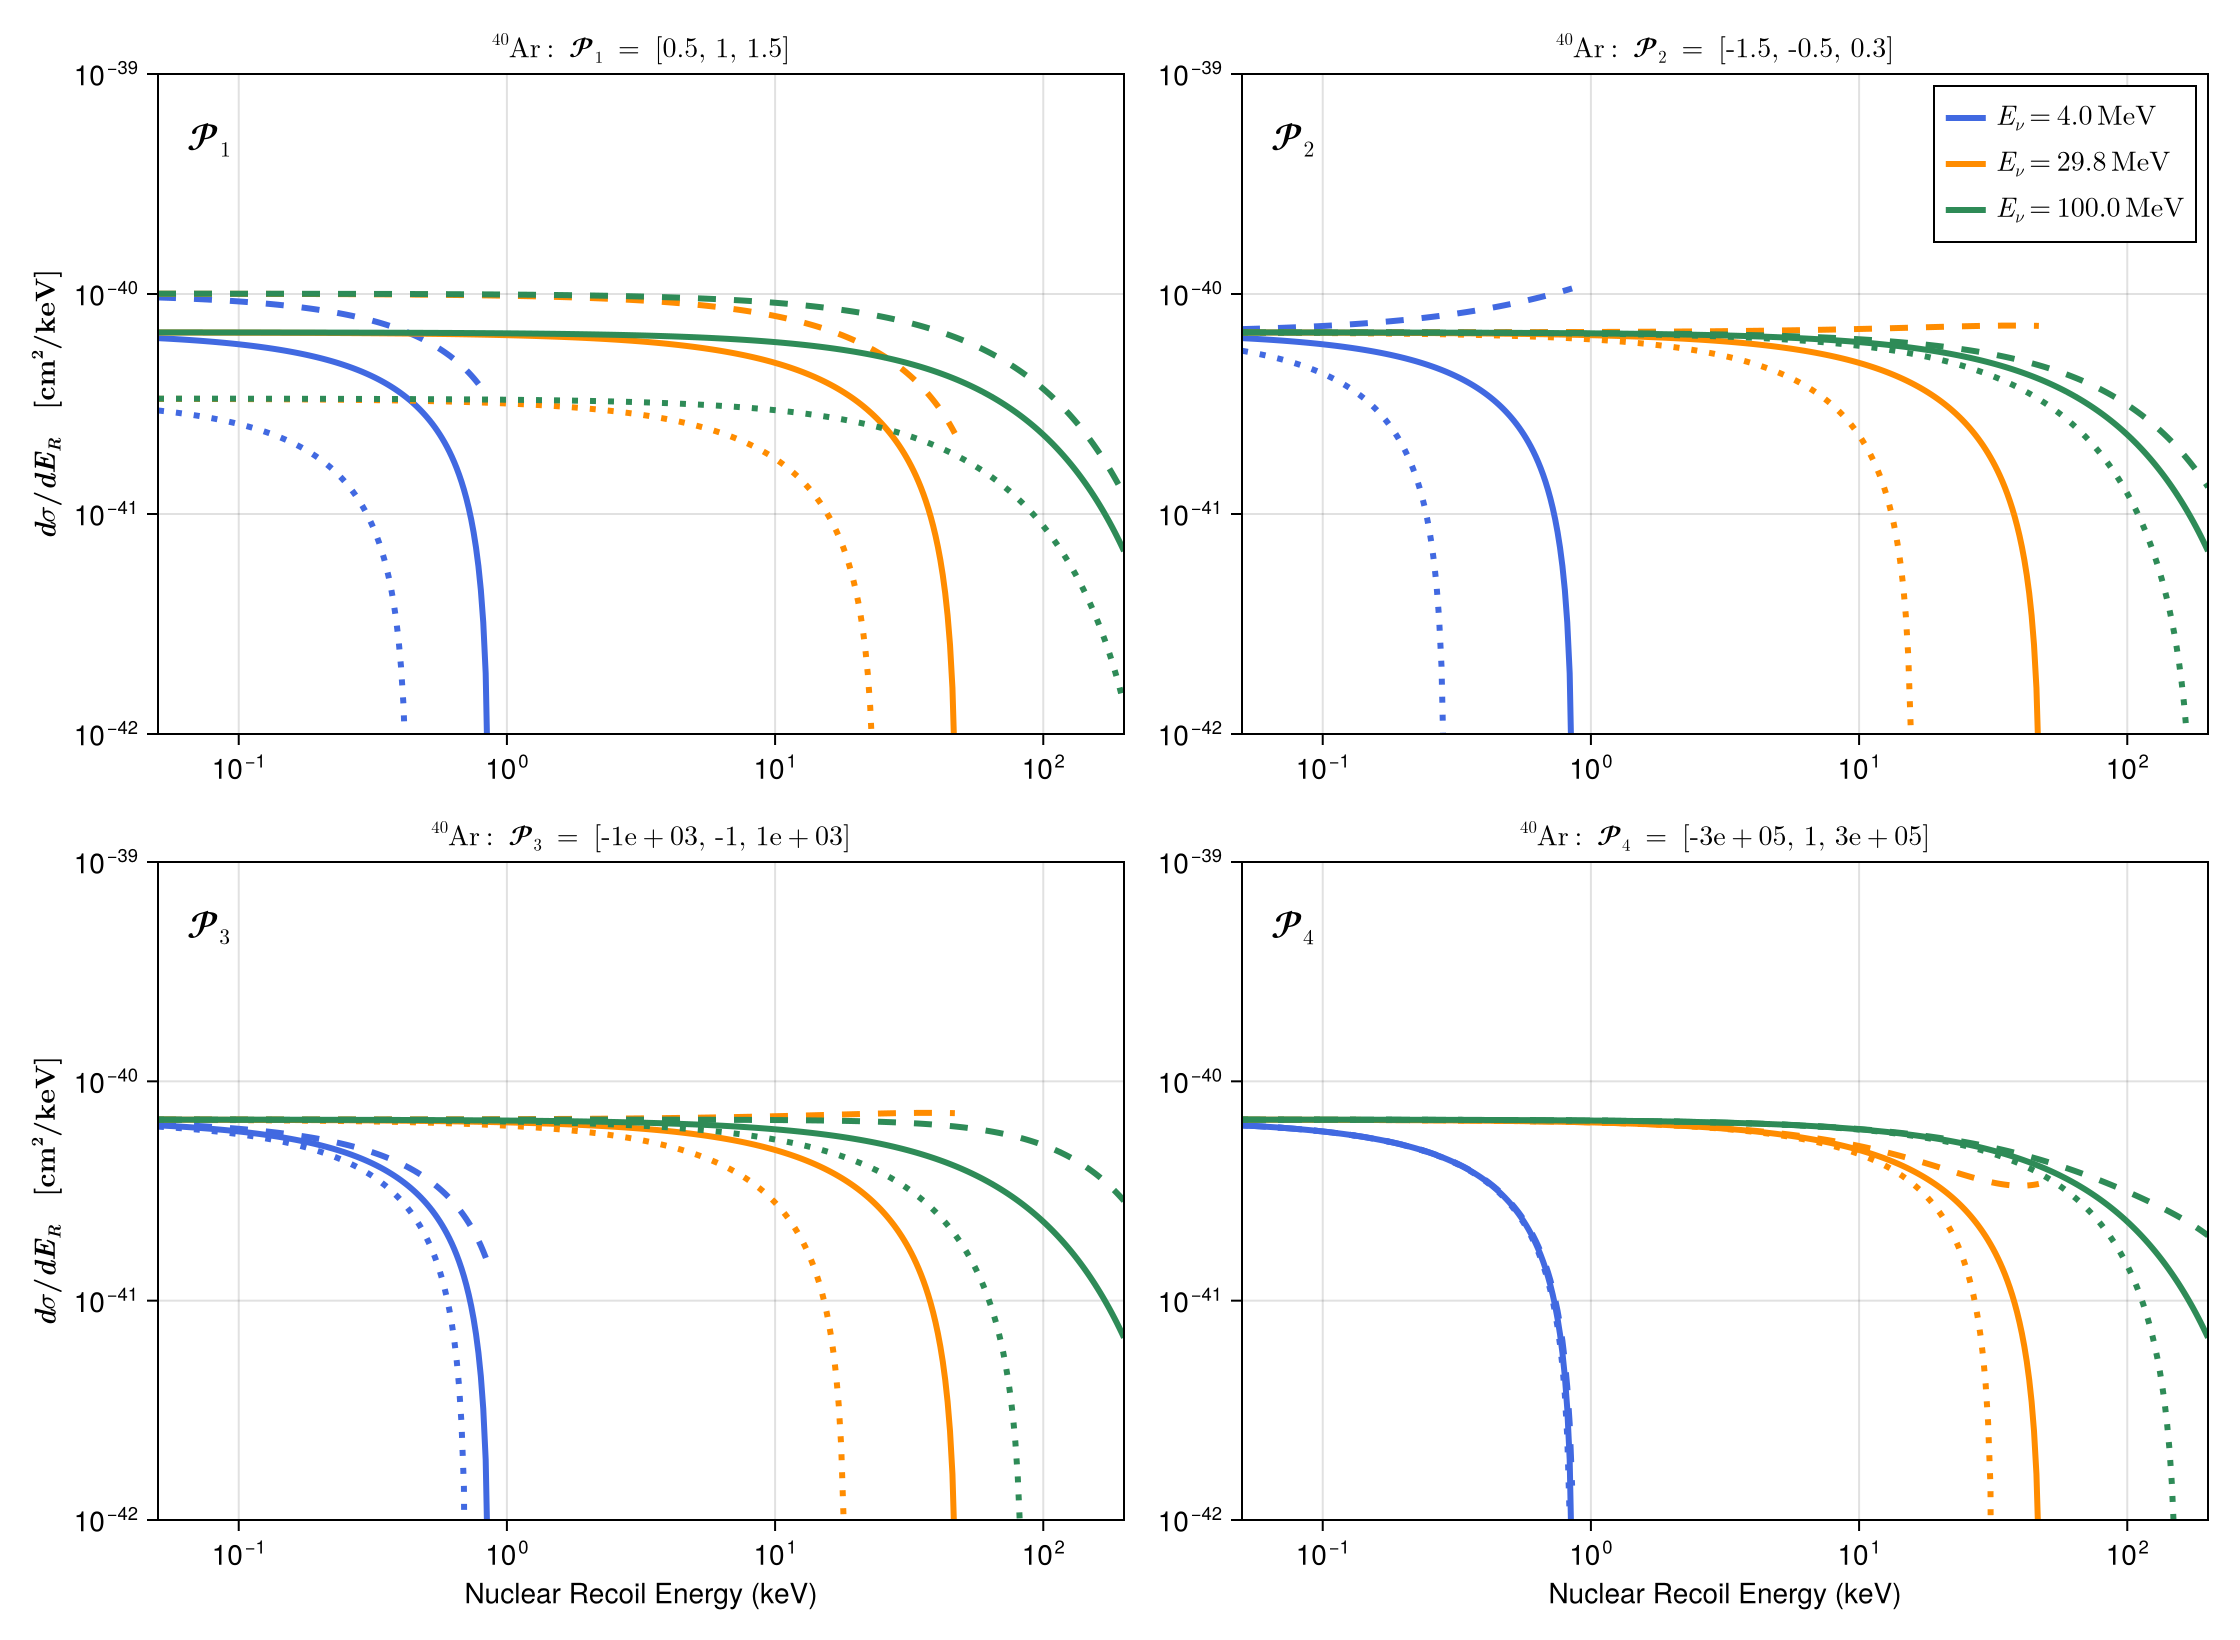

CairoMakie.Screen{IMAGE}


In [16]:
enu = [4.0, 29.8, 100.0]
er_keV = 10. .^ LinRange(-2, 2.5, 500)
er = er_keV .* 1e-3 # MeV input for CEvNS xsec

isotopes = [
    (fraction=0.49, mass=123.8e3, Z=55, N=78, Rn_key=:Rn_Cs, Rn_nom=5.00, label=L"^{133}\mathrm{Cs}"),
    (fraction=0.51, mass=118.21e3, Z=53, N=74, Rn_key=:Rn_I, Rn_nom=5.00, label=L"^{127}\mathrm{I}"),
    (fraction=1.0, mass=37.3e3, Z=18, N=22, Rn_key=:Rn_Ar, Rn_nom=3.6, label=L"^{40}\mathrm{Ar}"),
]

xsec = Newtrinos.cevns_xsec.configure(isotopes, er, enu)
xsec_params = xsec.params

const XSEC_PARAM_SYMS = (:cevns_xsec_a, :cevns_xsec_b, :cevns_xsec_c, :cevns_xsec_d)
const ENU_COLORS = [:royalblue, :darkorange, :seagreen]

function xsec_curve(xsec, iso, tested_sym, tested_val, enu_idx; scale=3.89379e-25)
    params = merge(xsec.params, NamedTuple{(tested_sym,)}((tested_val,)))
    xsec.diff_xsec(params)[iso.Rn_key][:, enu_idx] .* scale
end

function plot_isotope_panel(iso)
    fig = Figure(size=(1120, 820))
    pane_titles = Dict(
        :cevns_xsec_a => L"$\mathcal{P}_1$",
        :cevns_xsec_b => L"$\mathcal{P}_2$",
        :cevns_xsec_c => L"$\mathcal{P}_3$",
        :cevns_xsec_d => L"$\mathcal{P}_4$",
    )

    tested_ranges = Dict(
        :cevns_xsec_a => (0.5, 1.0, 1.5),
        :cevns_xsec_b => (-1.5, -0.5, 0.3),
        :cevns_xsec_c => (-1000.0, -1.0, 1000.0),
        :cevns_xsec_d => (-3e5, 1.0, 3e5),
    )

    axes = Matrix{Axis}(undef, 2, 2)
    for (i, sym) in enumerate(XSEC_PARAM_SYMS)
        row = cld(i, 2)
        col = mod1(i, 2)

        low_val, mid_val, high_val = tested_ranges[sym]
        vals = @sprintf("[%.3g, %.3g, %.3g]", low_val, mid_val, high_val)
        title_text = latexstring(string(iso.label, ": ", pane_titles[sym], " = ", vals))

        ax = Axis(
            fig[row, col],
            xscale=log10,
            yscale=log10,
            xlabel=(row == 2 ? "Nuclear Recoil Energy (keV)" : ""),
            ylabel=(col == 1 ? L"$\mathbf{{d\sigma}/{dE_R}\quad[\mathrm{cm}^2/\mathrm{keV}]}$" : ""),
            title=title_text,
        )
        axes[row, col] = ax

        for (enu_idx, enu_val) in enumerate(enu)
            color = ENU_COLORS[enu_idx]
            y_low = xsec_curve(xsec, iso, sym, low_val, enu_idx)
            y_mid = xsec_curve(xsec, iso, sym, mid_val, enu_idx)
            y_high = xsec_curve(xsec, iso, sym, high_val, enu_idx)
            y_lo = min.(y_low, y_high)
            y_hi = max.(y_low, y_high)

            #band!(ax, er_keV, y_lo, y_hi, color=(color, 0.18))
            lines!(ax, er_keV, y_low, color=color, linewidth=3, linestyle=:dot)
            lines!(ax, er_keV, y_mid, color=color, linewidth=3, label=latexstring(@sprintf("E_\\nu = %.1f\\,\\mathrm{MeV}", enu_val)))
            lines!(ax, er_keV, y_high, color=color, linewidth=3, linestyle=:dash)
        end

        text!(ax, 0.03, 0.93, text=pane_titles[sym], space=:relative, align=(:left, :top), fontsize=18)
        
        if iso.Rn_key == :Rn_Ar
            ylims!(ax, 1e-42, 1e-39)
            xlims!(ax, 0.05, 200)
        else
            ylims!(ax, 1e-41, 5e-38)
            xlims!(ax, 0.05, 100)
        end
    end

    axislegend(axes[1, 2], framevisible=true)
    fig
end

fig_csi = plot_isotope_panel(isotopes[1])
fig_i = plot_isotope_panel(isotopes[2])
fig_ar = plot_isotope_panel(isotopes[3])

save("coherent_postPred/xsec_csi.png", fig_csi)
save("coherent_postPred/xsec_i.png", fig_i)
save("coherent_postPred/xsec_ar.png", fig_ar)
save("coherent_postPred/xsec_csi.pdf", fig_csi)
save("coherent_postPred/xsec_i.pdf", fig_i)
save("coherent_postPred/xsec_ar.pdf", fig_ar)
display(fig_csi)
display(fig_i)
display(fig_ar)

In [ ]:
function  rhelm(rn,s_fm)
    r0_fm = sqrt((5/3)*(rn^2-(3*s_fm^2)))
    return r0_fm
end

function rkn(rn,a_fm)
    r0_fm = sqrt((rn^2 - 6*a_fm^2)*(5/3))
    return r0_fm
end
function rkn_current(rn,a)
    r0 = (3/5)*rn
    return sqrt(r0sq)
end

rkn_current (generic function with 1 method)

In [17]:
r_csi_helm = rhelm(4.7,0.9)
r_csi_kn = rkn(4.7,0.7)
r_ar_helm = rhelm(3.6,0.9)
r_ar_kn = rkn(3.6,0.7)
println("R0 Helm CsI: ", r_csi_helm)
println("R0 KN CsI: ", r_csi_kn)
println("R0 Helm Ar: ", r_ar_helm)
println("R0 KN Ar: ", r_ar_kn)

R0 Helm CsI: 5.724217559340898
R0 KN CsI: 5.649483752226098
R0 Helm Ar: 4.189272013130683
R0 KN Ar: 4.08656334834051


In [10]:
rkn(4.7,0.7)

5.649483752226098

In [8]:
sqrt(5 / 3) * 4.1

5.293077239816802

In [69]:
xsec.params

(Rn_I = 5.7242, cevns_xsec_a = 1.0, Rn_Ar = 4.1039, cevns_xsec_b = -0.5, cevns_xsec_c = -1.0, sin2thetaW = 0.231, Rn_Cs = 5.7242, cevns_xsec_d = 1.0)

In [70]:
params = merge(xsec.params, NamedTuple{(:cevns_xsec_a,)}((1.5,)))
print("Updated parameters: ", params)

Updated parameters: (Rn_I = 5.7242, cevns_xsec_a = 1.5, Rn_Ar = 4.1039, cevns_xsec_b = -0.5, cevns_xsec_c = -1.0, sin2thetaW = 0.231, Rn_Cs = 5.7242, cevns_xsec_d = 1.0)

In [ ]:
y_low = xsec_curve(xsec, iso, sym, low_val, 1)

LoadError: UndefVarError: `y_low` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
enu = 10. .^LinRange(0, 2, 7)
er_keV = 10. .^LinRange(-2, 2, 500)
er = er_keV .* 1e-3 # Convert to MeV

isotopes = [
    (fraction=1.0, mass=123.8e3, Z=55, N=78, Rn_key=:Rn_Cs, Rn_nom=5.7242, label="Cs-133"),
    (fraction=1.0, mass=118.21e3, Z=53, N=74, Rn_key=:Rn_I, Rn_nom=5.7242, label="I-127"),
    (fraction=1.0, mass=37.3e3, Z=18, N=22, Rn_key=:Rn_Ar, Rn_nom=4.1039, label="Ar-37"),
]
xsec = Newtrinos.cevns_xsec.configure(isotopes, er, enu)
p = xsec.params
pr = xsec.priors
xsec.diff_xsec(p)

[ Info: Configuring CEvNS cross-section assets


Newtrinos.cevns_xsec.CevnsXsec((Rn_I = 5.7242, cevns_xsec_a = 1.0, Rn_Ar = 4.1039, cevns_xsec_b = -0.5, cevns_xsec_c = -1.0, sin2thetaW = 0.231, Rn_Cs = 5.7242, cevns_xsec_d = 1.0), (Rn_I = Distributions.Uniform{Float64}(a=5.43799, b=6.010409999999999), cevns_xsec_a = Distributions.Uniform{Float64}(a=0.0, b=2.0), Rn_Ar = Distributions.Uniform{Float64}(a=3.8987050000000005, b=4.309095), cevns_xsec_b = Distributions.Uniform{Float64}(a=-2.0, b=1.0), cevns_xsec_c = Distributions.Uniform{Float64}(a=-3000.0, b=3000.0), sin2thetaW = Truncated(Distributions.Normal{Float64}(μ=0.231, σ=0.00013); lower=0.2, upper=0.26), Rn_Cs = Distributions.Uniform{Float64}(a=5.43799, b=6.010409999999999), cevns_xsec_d = Distributions.Uniform{Float64}(a=-1.0e6, b=1.0e6)), Newtrinos.cevns_xsec.var"#get_diff_xsec##0#get_diff_xsec##1"{Newtrinos.cevns_xsec.var"#ffsq##0#ffsq##1"{@NamedTuple{}, Symbol}, Dict{Symbol, @NamedTuple{mass::Float64, Z::Int64, N::Int64, fraction::Float64, Rn_nom::Float64}}, Vector{Float64}, V

*Liquid-Ar Detector*

expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]

[ Info: Loading coherent lAr data
[ Info: Configuring CEvNS cross-section assets



sum(expected_counts_nom) = 127.11966586590307
expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]
sum(expected_counts_nom) = 127.11966586590307
expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]
sum(expected_counts_nom) = 127.11966586590307
expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]
sum(expected_counts_nom) = 127.11966586590307


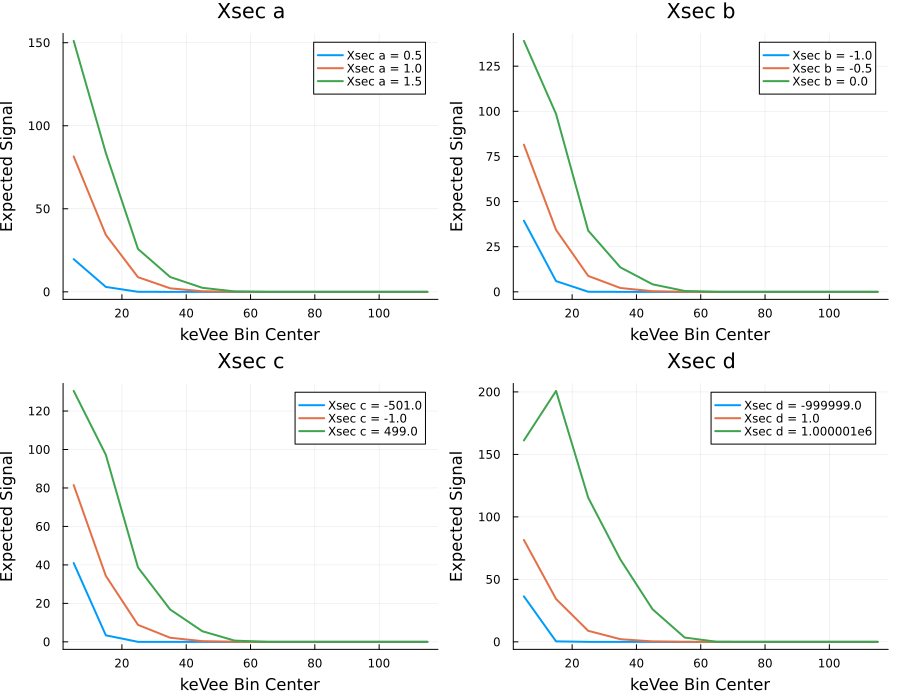

In [11]:
# Check dependence of expected signal PE projection on cevns_xsec parameters (l-Ar)

coherent_lAr = Newtrinos.coherent_lAr.configure()
physics = coherent_lAr.physics
assets = coherent_lAr.assets
p_nom = Newtrinos.get_params(coherent_lAr)
keVee_centers = assets.out_centers
f90_centers = assets.f90_centers
timing_centers = assets.timing_centers

n_keVee_bins = length(keVee_centers)
n_f90_bins = length(f90_centers)
n_timing_bins = length(timing_centers)

function compute_projection(data, bin_centers, col_index)
    proj = zeros(length(bin_centers))
    for i in 1:length(bin_centers)
        proj[i] = sum(data[data[:, col_index] .== bin_centers[i], 4])
    end
    return proj
end

param_syms = [:cevns_xsec_a, :cevns_xsec_b, :cevns_xsec_c, :cevns_xsec_d]
param_labels = ["Xsec a", "Xsec b", "Xsec c", "Xsec d"]
param_scales = [0.5, 0.5, 5e2, 1e6]  # additive offsets around the current nominal values

plots = []
for (i, sym) in enumerate(param_syms)
    plt = Plots.plot()
    nominal_val = p_nom[sym]
    for val in [-1.0, 0.0, 1.0]
        p = deepcopy(p_nom)
        test_val = nominal_val + val * param_scales[i]
        p = merge(p, (sym => test_val,))
        expected_counts = Newtrinos.coherent_lAr.get_expected(p, physics, assets)
        data_signal = hcat(
            repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
            repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
            repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
            expected_counts
        )
        proj_keVee_signal = compute_projection(data_signal, keVee_centers, 1)
        label_str = param_scales[i] == 1 ? "$(param_labels[i]) = $val" : "$(param_labels[i]) = $test_val"
        Plots.plot!(plt, keVee_centers, proj_keVee_signal, label=label_str, lw=2)
    end
    Plots.plot!(plt, xlabel="keVee Bin Center", ylabel="Expected Signal", title=param_labels[i])
    push!(plots, plt)
    expected_counts_nom = Newtrinos.coherent_lAr.get_expected(p_nom, physics, assets)
    @show expected_counts_nom[1:10]
    @show sum(expected_counts_nom)
end
Plots.plot(plots..., layout=(2,2), size=(900,700))

[ Info: Flux is not fully configured yet.
[ Info: Loading and binning CsI data
[ Info: Configuring Flux
[ Info: Configuring CEvNS cross-section assets
[ Info: Configured COHERENT CsI module.
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/scenes.jl:264
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


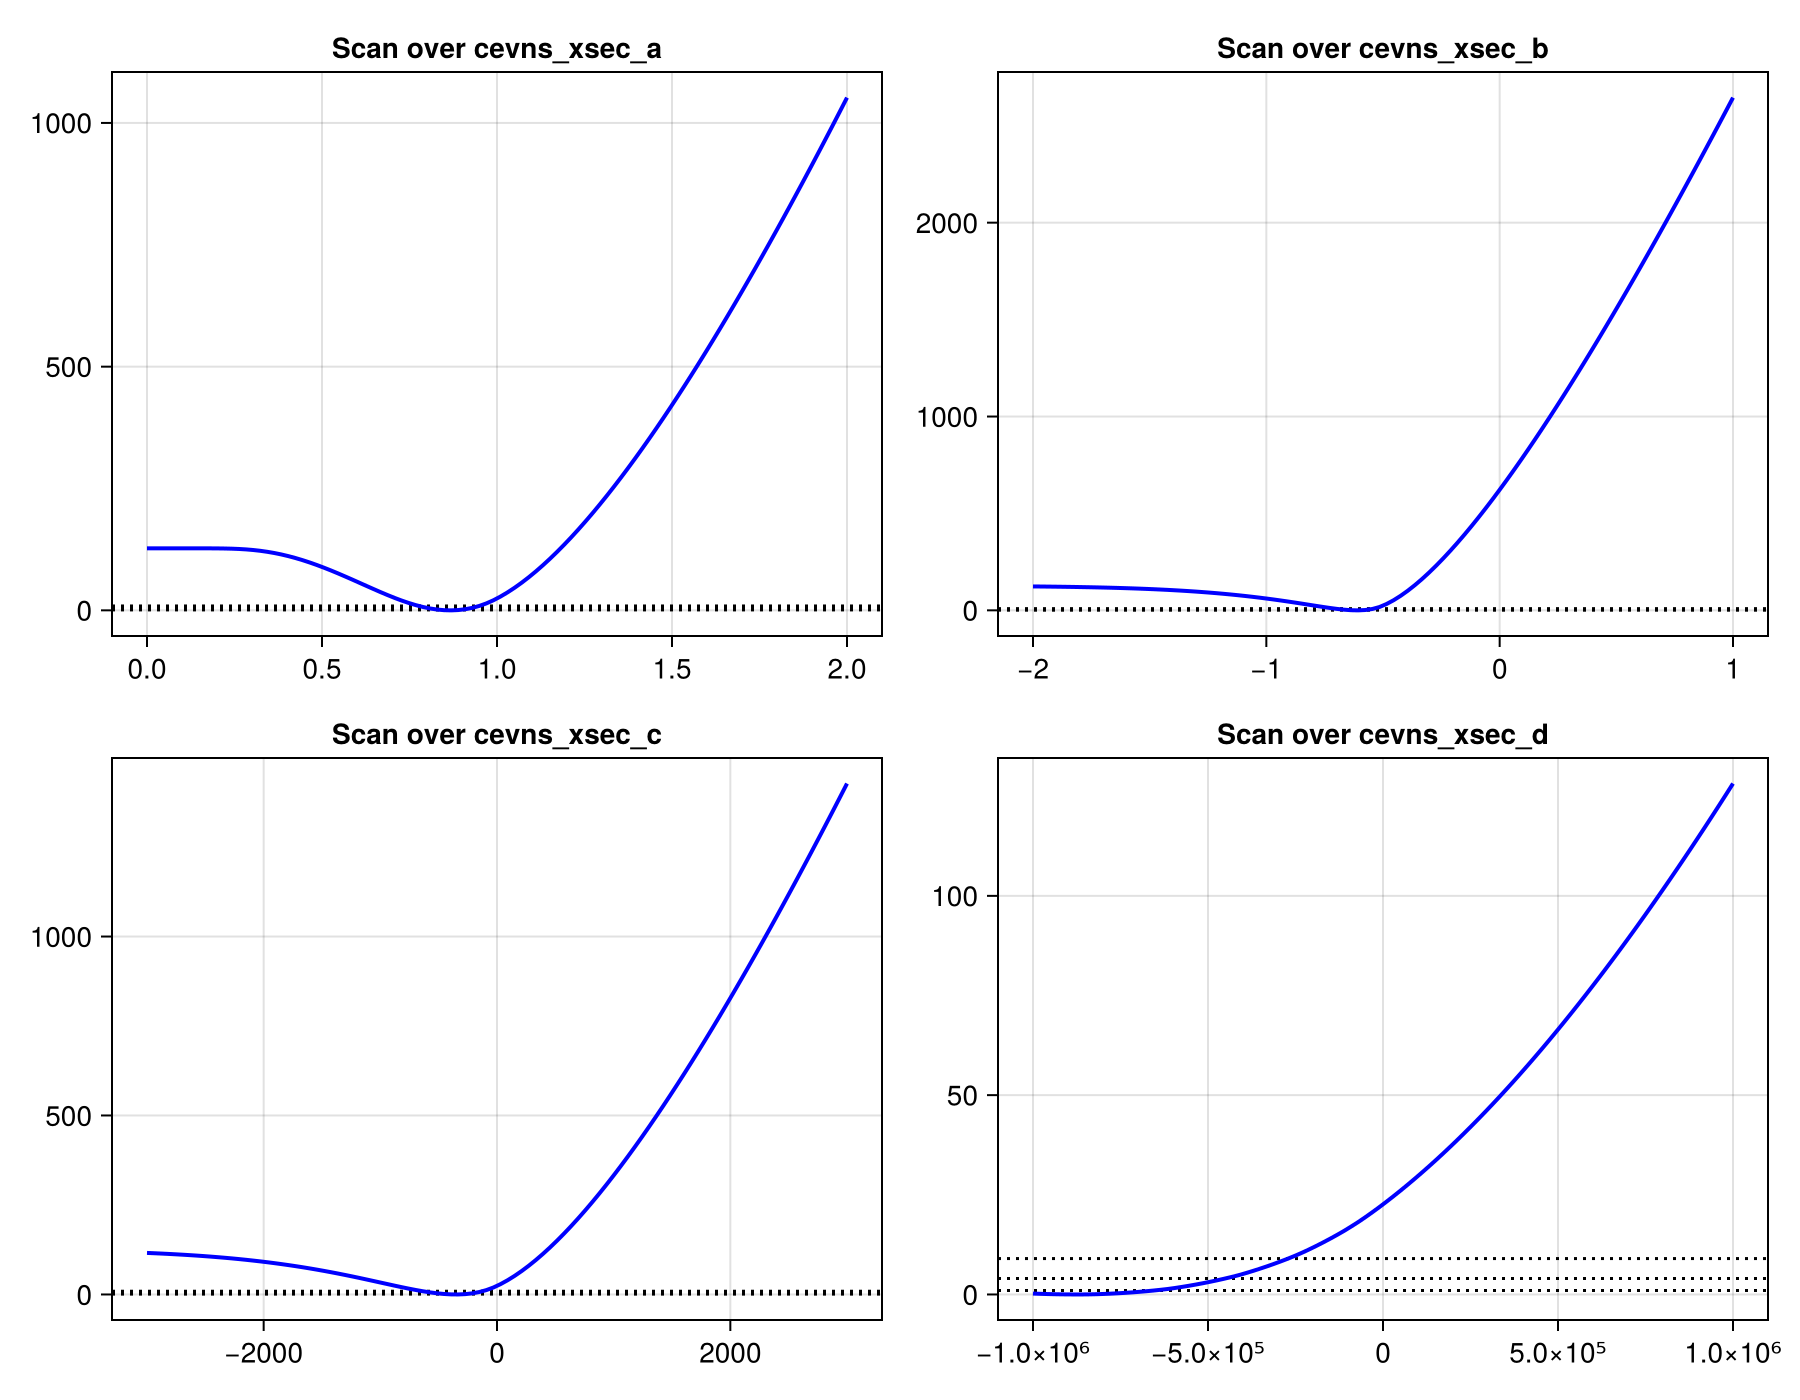

In [12]:
using CairoMakie

coherent_csi = Newtrinos.coherent_csi.configure()
#coherent_lAr = Newtrinos.coherent_lAr.configure()
experiments = (; coherent_csi)

likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)


scan_params = [
    (:cevns_xsec_a, 100, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 100, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 100, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 100, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.scan(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig

In [13]:
using BAT
prior = distprod(;priors...)
bestfit = Newtrinos.find_mle(likelihood, prior, p)

[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x15c6f7001f98145a, 0xfbfc993352f50416, 0x1127b903387fa58c, 0x5f1b999d2696599e, 0x3a460f9cb59482da, 0x94aaeaddbef123e0, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), ADTypes.NoAutoDiff())
[ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0x15c6f7001f98145a, 0xfbfc993352f50416, 0x1127b903387fa58c, 0x5f1b999d2696599e, 0x3a460f9cb59482da, 0x94aaeaddbef123e0, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())
[ Info: Running Optimization for point 


(-467.99153014322764, -507.16513860560275, (Rn_Cs = 7.716696460487459, Rn_I = 5.473800625857117, brn_norm = 37.69045092660532, cevns_xsec_a = 1.168452448975828, cevns_xsec_b = -0.6604307338413222, cevns_xsec_c = -559.8750576329521, cevns_xsec_d = 999740.0763621018, coherent_csi_eff_sigma = 0.28576088497865193, coherent_csi_qf_pc0 = 0.030926080149758405, coherent_csi_qf_pc1 = 0.01766871120115637, flux_norm = 1.0014350939571768, flux_onset = 15.919943796140737, nin_norm = 7.340430452882335, sin2thetaW = 0.23100001640546702, ss_bkg_norm = 3864.764606670808))

[ Info: Loading coherent lAr data
[ Info: Configuring CEvNS cross-section assets
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/scenes.jl:264
Progress: 100%|█████████████████████████████████████████| Time: 0:00:03
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


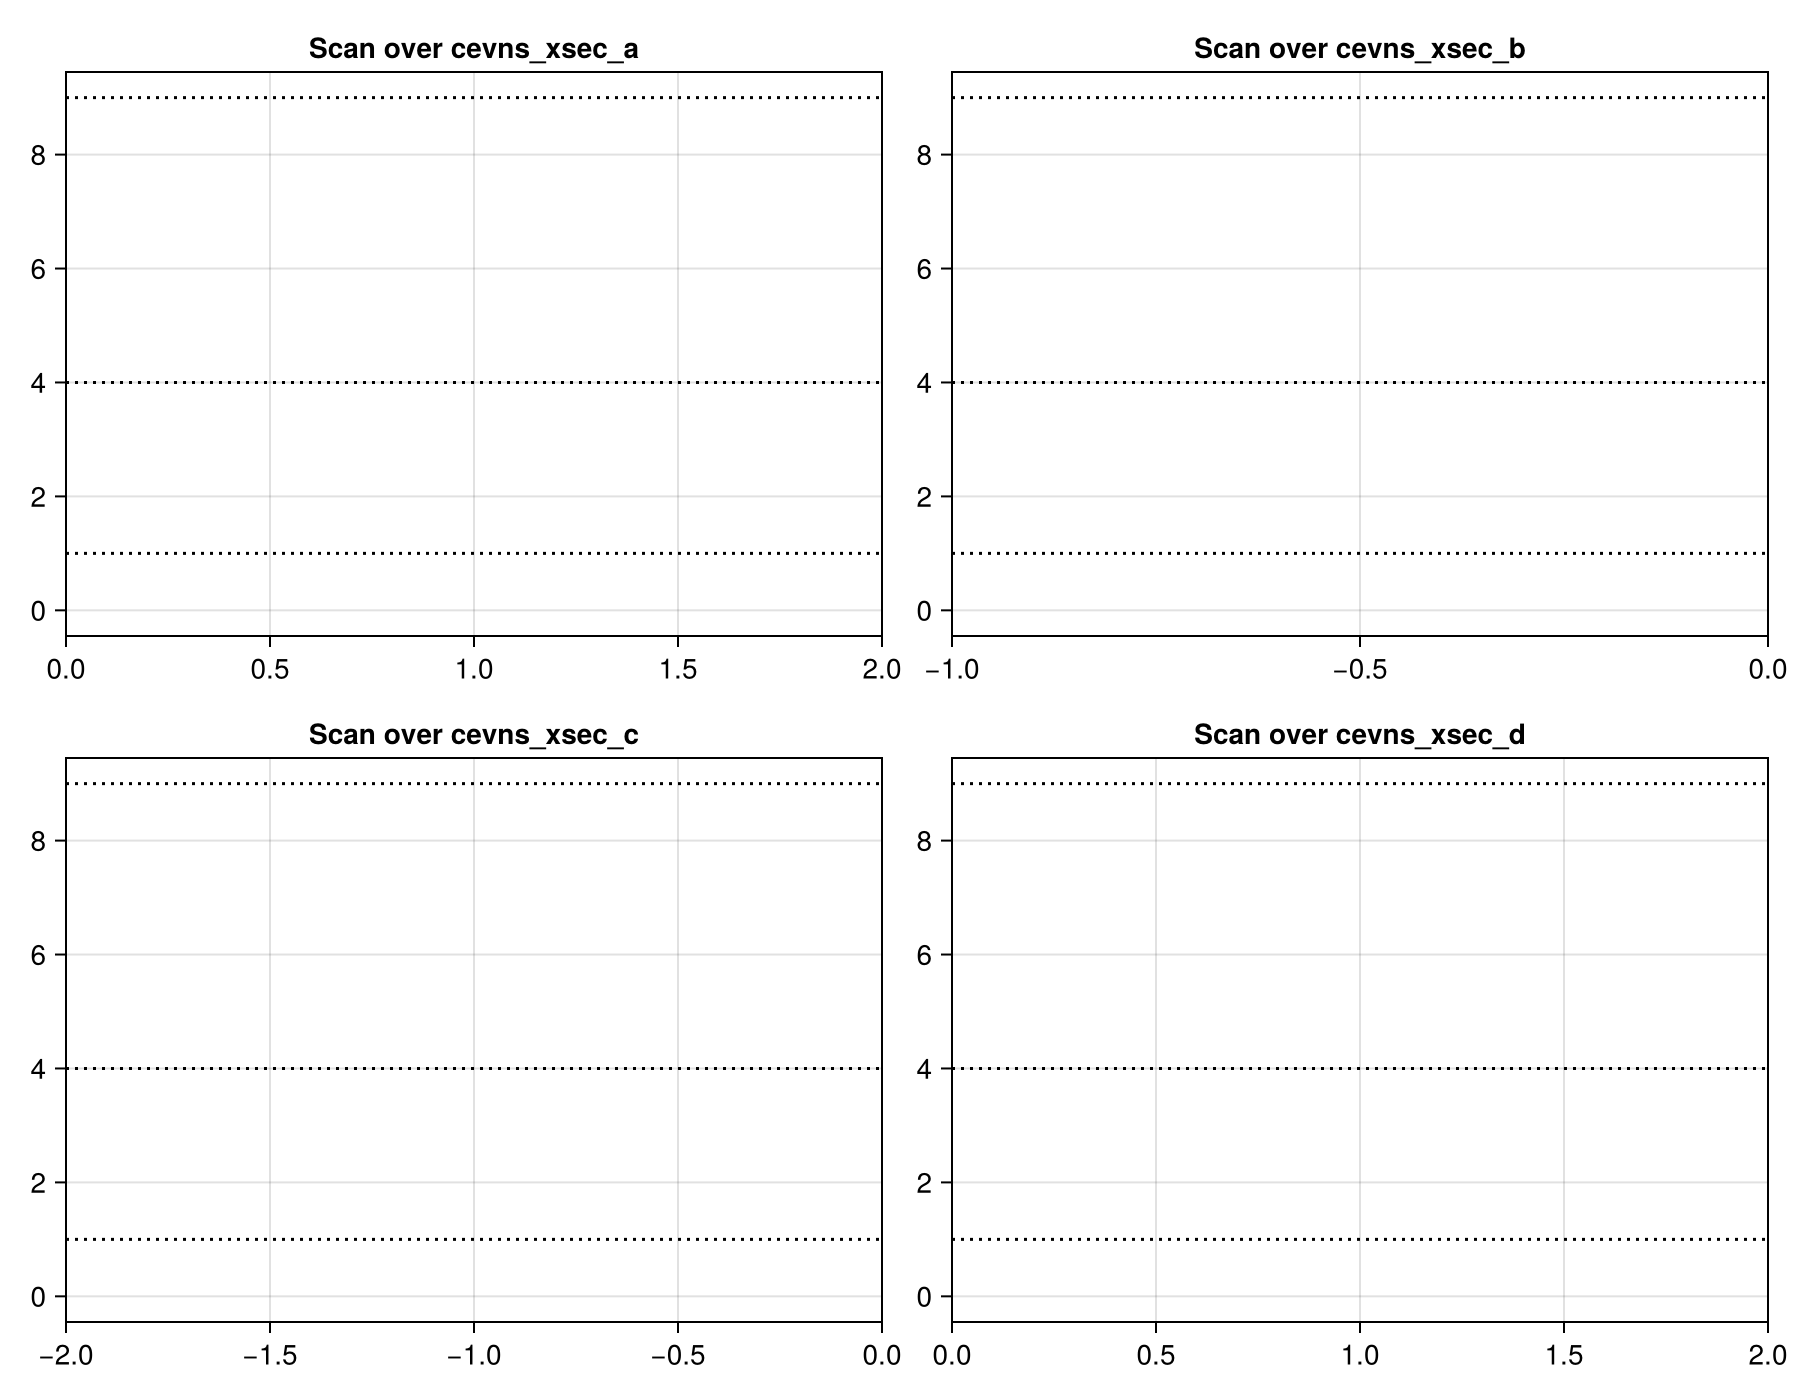

In [3]:
using CairoMakie
using Accessors
coherent_lAr = Newtrinos.coherent_lAr.configure()
experiments = (; coherent_lAr)

likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)
@reset priors.cevns_xsec_a = p.cevns_xsec_a
@reset priors.cevns_xsec_b = p.cevns_xsec_b
@reset priors.cevns_xsec_c = p.cevns_xsec_c
@reset priors.cevns_xsec_d = p.cevns_xsec_d

scan_params = [
    (:cevns_xsec_a, 100, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 100, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 100, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 100, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.scan(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig

In [4]:
using BAT
prior = distprod(;priors...)
bestfit_SM = Newtrinos.find_mle(likelihood, prior, p)

[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x4a879489599c8cc4, 0x7bb253faa43f6be3, 0x6ad216247b2b9f79, 0x5573c9c895fa57b2, 0x58d1b66c54bbc185, 0x31e765fbc47060db, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), ADTypes.NoAutoDiff())
[ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0x4a879489599c8cc4, 0x7bb253faa43f6be3, 0x6ad216247b2b9f79, 0x5573c9c895fa57b2, 0x58d1b66c54bbc185, 0x31e765fbc47060db, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())
[ Info: Running Optimization for point  cevns_xsec_a: 1.0 cevns_xsec_b: -0.5 cevns_xsec_c: -1.0 cevns_xsec_d: 1.0


(-1749.8863720951992, -1739.93811058341, (Rn_Ar = 3.898711737182994, cevns_xsec_a = 1.0, cevns_xsec_b = -0.5, cevns_xsec_c = -1.0, cevns_xsec_d = 1.0, coherent_lar_delbrn_norm = 13.513828915350636, coherent_lar_mass = 24.41135607090342, coherent_lar_pbrn_norm = 566.5225167955397, coherent_lar_qfa_a = 0.24636794057348935, coherent_lar_qfa_b = 0.0007808447848412861, coherent_lar_ss_bkg_norm = 3132.9015983667337, sin2thetaW = 0.23100008787073686, sns_nu_per_POT = 0.09066542703560614))

In [5]:
using BAT
prior = distprod(;priors...)
bestfit = Newtrinos.find_mle(likelihood, prior, p)

[ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0x402cc64e7a624b93, 0x8595acd1dbc76d36, 0xb069c711bdbc3ae4, 0xf9eca130a4dbcfc0, 0x41cf2dc74b835ac4, 0xc77ebc352b55235a, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())
[ Info: Running Optimization for point 


(-1748.4615758586551, -1763.5791993710127, (Rn_Ar = 3.899381725280105, cevns_xsec_a = 2.892642142354316e-17, cevns_xsec_b = -0.43762590338217633, cevns_xsec_c = 1843.4641869310653, cevns_xsec_d = -680955.8399498956, coherent_lar_delbrn_norm = 10.980537926040917, coherent_lar_mass = 24.39978172768244, coherent_lar_pbrn_norm = 552.2177595372126, coherent_lar_qfa_a = 0.2460704272824569, coherent_lar_qfa_b = 0.0007795040855306499, coherent_lar_ss_bkg_norm = 3131.068680235792, sin2thetaW = 0.23099999848878905, sns_nu_per_POT = 0.08998862051873222))

In [5]:
println("Total fit signal counts: ", sum(Newtrinos.coherent_lAr.get_expected(bestfit[3], coherent_lAr.physics, coherent_lAr.assets)))

Total fit signal counts: 160.19135347989024


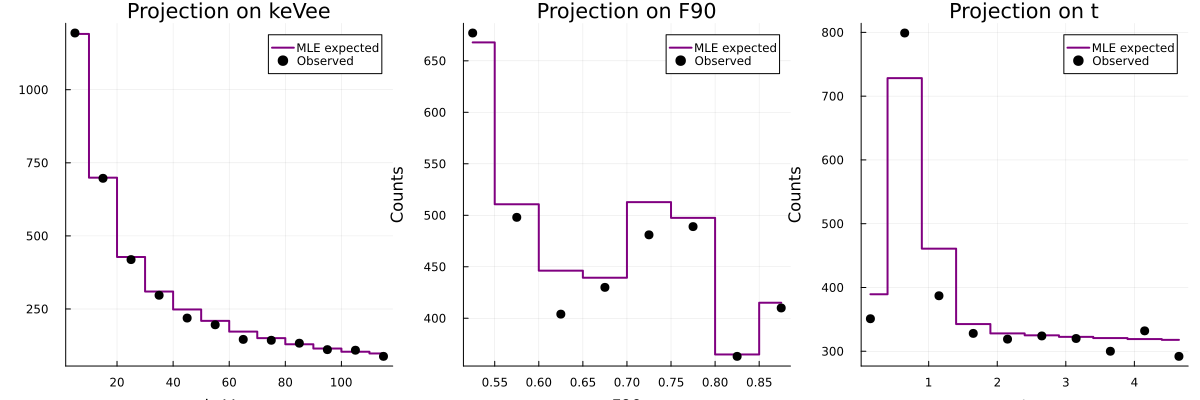

In [6]:
bf = bestfit[3]
signal_mle = Newtrinos.coherent_lAr.get_expected(bf, coherent_lAr.physics, coherent_lAr.assets)
bkg_brn_mle, bkg_delbrn_mle, bkg_ss_bkg_mle = Newtrinos.coherent_lAr.get_backgrounds(bf, coherent_lAr.assets)
expected_mle = signal_mle .+ bkg_brn_mle .+ bkg_delbrn_mle .+ bkg_ss_bkg_mle
observed_mle = coherent_lAr.assets.observed

keVee_centers = coherent_lAr.assets.out_centers
f90_centers = coherent_lAr.assets.f90_centers
timing_centers = coherent_lAr.assets.timing_centers

n_keVee_bins = length(keVee_centers)
n_f90_bins = length(f90_centers)
n_timing_bins = length(timing_centers)

expected_reshaped = permutedims(
    reshape(expected_mle, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
 )
observed_reshaped = permutedims(
    reshape(observed_mle, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
 )

proj_keVee_expected = dropdims(sum(expected_reshaped, dims=(2, 3)), dims=(2, 3))
proj_keVee_observed = dropdims(sum(observed_reshaped, dims=(2, 3)), dims=(2, 3))
proj_F90_expected = dropdims(sum(expected_reshaped, dims=(1, 3)), dims=(1, 3))
proj_F90_observed = dropdims(sum(observed_reshaped, dims=(1, 3)), dims=(1, 3))
proj_t_expected = dropdims(sum(expected_reshaped, dims=(1, 2)), dims=(1, 2))
proj_t_observed = dropdims(sum(observed_reshaped, dims=(1, 2)), dims=(1, 2))

plt_pe = Plots.plot(keVee_centers, proj_keVee_expected; label="MLE expected", seriestype=:stepmid, lw=2, color=:purple, xlabel="keVee", ylabel="Counts", title="Projection on keVee")
Plots.scatter!(plt_pe, keVee_centers, proj_keVee_observed; label="Observed", color=:black, marker=:circle, markersize=5)

plt_f90 = Plots.plot(f90_centers, proj_F90_expected; label="MLE expected", seriestype=:stepmid, lw=2, color=:purple, xlabel="F90", ylabel="Counts", title="Projection on F90")
Plots.scatter!(plt_f90, f90_centers, proj_F90_observed; label="Observed", color=:black, marker=:circle, markersize=5)

plt_t = Plots.plot(timing_centers, proj_t_expected; label="MLE expected", seriestype=:stepmid, lw=2, color=:purple, xlabel="t", ylabel="Counts", title="Projection on t")
Plots.scatter!(plt_t, timing_centers, proj_t_observed; label="Observed", color=:black, marker=:circle, markersize=5)

Plots.plot(plt_pe, plt_f90, plt_t, layout=(1, 3), size=(1200, 400))

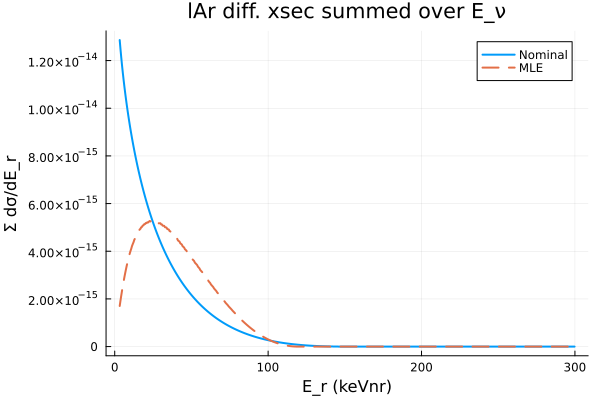

In [7]:
p_nom_lar = Newtrinos.get_params(coherent_lAr)
p_mle_lar = bestfit[3]

diff_xsec_nom = coherent_lAr.physics.cevns_xsec.diff_xsec(p_nom_lar)[:Rn_Ar]
diff_xsec_mle = coherent_lAr.physics.cevns_xsec.diff_xsec(p_mle_lar)[:Rn_Ar]

diff_xsec_nom_er = vec(sum(diff_xsec_nom, dims=2))
diff_xsec_mle_er = vec(sum(diff_xsec_mle, dims=2))

er_centers_keVnr = coherent_lAr.assets.er_centers

Plots.plot(
    er_centers_keVnr,
    diff_xsec_nom_er;
    label="Nominal",
    lw=2,
    xlabel="E_r (keVnr)",
    ylabel="Σ dσ/dE_r",
    title="lAr diff. xsec summed over E_ν"
 )
Plots.plot!(
    er_centers_keVnr,
    diff_xsec_mle_er;
    label="MLE",
    lw=2,
    linestyle=:dash
 )

In [2]:
using BAT
using Distributions
using Newtrinos
using StatsBase
using Plots

coherent_lAr_full = Newtrinos.coherent_lAr.configure()

function lar_kevee_mask(assets; drop_bins = [1])
    n_keVee = length(assets.out_centers)
    n_f90 = length(assets.f90_centers)
    n_t = length(assets.timing_centers)

    keep_keVee = trues(n_keVee)
    keep_keVee[drop_bins] .= false

    mask = falses(n_keVee * n_f90 * n_t)
    idx = 1
    for i in 1:n_keVee, j in 1:n_f90, k in 1:n_t
        mask[idx] = keep_keVee[i]
        idx += 1
    end
    return mask
end

mask = lar_kevee_mask(coherent_lAr_full.assets; drop_bins = [1])

assets_cut = merge(
    coherent_lAr_full.assets,
    (
        observed = coherent_lAr_full.assets.observed[mask],
        fit_mask = mask,
        fit_out_centers = coherent_lAr_full.assets.out_centers[2:end],
    )
)

forward_model_cut = let physics = coherent_lAr_full.physics, assets = assets_cut
    function (params)
        signal = Newtrinos.coherent_lAr.get_expected(params, physics, assets)
        bkg_pbrn, bkg_delbrn, bkg_ss_bkg = Newtrinos.coherent_lAr.get_backgrounds(params, assets)
        exp_events = signal .+ bkg_pbrn .+ bkg_delbrn .+ bkg_ss_bkg
        distprod(Poisson.(exp_events[assets.fit_mask]))
    end
end

coherent_lAr_cut = Newtrinos.coherent_lAr.COHERENT_LAR(
    physics = coherent_lAr_full.physics,
    params = coherent_lAr_full.params,
    priors = coherent_lAr_full.priors,
    assets = assets_cut,
    forward_model = forward_model_cut,
    plot = coherent_lAr_full.plot,
)

[ Info: Loading coherent lAr data
[ Info: Configuring CEvNS cross-section assets


Newtrinos.coherent_lAr.COHERENT_LAR((sns_flux = Newtrinos.sns_flux.SNSFlux((sns_nu_per_POT = 0.09,), (sns_nu_per_POT = Truncated(Normal{Float64}(μ=0.09, σ=0.009); lower=0.05, upper=0.15),), (E = [0.5, 1.0028846153846154, 1.5057692307692307, 2.0086538461538463, 2.5115384615384615, 3.014423076923077, 3.5173076923076922, 4.020192307692308, 4.523076923076923, 5.025961538461538  …  48.27403846153846, 48.776923076923076, 49.27980769230769, 49.78269230769231, 50.285576923076924, 50.78846153846154, 51.291346153846156, 51.79423076923077, 52.29711538461538, 52.8], flux_mu = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], flux_e = [5.6827362340820775e-12, 2.2642444588484484e-11, 5.054767206016002e-11, 8.906677468303871e-11, 1.3786810849105055e-10, 1.9662002951812567e-10, 2.649908937981939e-10, 3.4264905736518547e-10, 4.2926287625303026e-10, 5.245007064956583e-10  …  4.584098324951177e-9, 4.160092040944087e-9, 3.715525099277617e-9, 3.2500658

In [3]:
experiments = (; coherent_lAr = coherent_lAr_cut)

likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)

prior = distprod(; priors...)
bestfit_cut = Newtrinos.find_mle(likelihood, prior, p)

[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x81d629027b4f84bb, 0x74b84bc2281dfe04, 0x69799fc8b9adc01e, 0xa2689d990a702b31, 0xd4c4f7beb743d63d, 0x97eb128932e45e24, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), ADTypes.NoAutoDiff())
[ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0x81d629027b4f84bb, 0x74b84bc2281dfe04, 0x69799fc8b9adc01e, 0xa2689d990a702b31, 0xd4c4f7beb743d63d, 0x97eb128932e45e24, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())
[ Info: Running Optimization for point 


(-1538.468862752548, -1553.5721370204128, (Rn_Ar = 3.898705629392122, cevns_xsec_a = 0.5254664552799222, cevns_xsec_b = -1.520470959632675, cevns_xsec_c = 2984.277397117813, cevns_xsec_d = -1.0e6, coherent_lar_delbrn_norm = 11.95038587172214, coherent_lar_mass = 24.400776485790075, coherent_lar_pbrn_norm = 544.4277837620948, coherent_lar_qfa_a = 0.24599622932650114, coherent_lar_qfa_b = 0.0007795451480016785, coherent_lar_ss_bkg_norm = 3130.4491275541686, sin2thetaW = 0.23100000555257896, sns_nu_per_POT = 0.09003973577060208))

In [4]:
println("Total fit signal counts: ", sum(Newtrinos.coherent_lAr.get_expected(bestfit_cut[3], coherent_lAr_cut.physics, coherent_lAr_cut.assets)))

Total fit signal counts: 201.80063458572567


In [5]:
bf = bestfit_cut[3]
signal_mle = Newtrinos.coherent_lAr.get_expected(bf, coherent_lAr_cut.physics, coherent_lAr_cut.assets)
bkg_brn_mle, bkg_delbrn_mle, bkg_ss_bkg_mle = Newtrinos.coherent_lAr.get_backgrounds(bf, coherent_lAr_cut.assets)
expected_mle = signal_mle .+ bkg_brn_mle .+ bkg_delbrn_mle .+ bkg_ss_bkg_mle
observed_mle = coherent_lAr_cut.assets.observed

keVee_centers = coherent_lAr_cut.assets.out_centers
f90_centers = coherent_lAr_cut.assets.f90_centers
timing_centers = coherent_lAr_cut.assets.timing_centers

n_keVee_bins = length(keVee_centers)
n_f90_bins = length(f90_centers)
n_timing_bins = length(timing_centers)

expected_reshaped = permutedims(
    reshape(expected_mle, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
 )
observed_reshaped = permutedims(
    reshape(observed_mle, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
 )

proj_keVee_expected = dropdims(sum(expected_reshaped, dims=(2, 3)), dims=(2, 3))
proj_keVee_observed = dropdims(sum(observed_reshaped, dims=(2, 3)), dims=(2, 3))
proj_F90_expected = dropdims(sum(expected_reshaped, dims=(1, 3)), dims=(1, 3))
proj_F90_observed = dropdims(sum(observed_reshaped, dims=(1, 3)), dims=(1, 3))
proj_t_expected = dropdims(sum(expected_reshaped, dims=(1, 2)), dims=(1, 2))
proj_t_observed = dropdims(sum(observed_reshaped, dims=(1, 2)), dims=(1, 2))

plt_pe = Plots.plot(keVee_centers, proj_keVee_expected; label="MLE expected", seriestype=:stepmid, lw=2, color=:purple, xlabel="keVee", ylabel="Counts", title="Projection on keVee")
Plots.scatter!(plt_pe, keVee_centers, proj_keVee_observed; label="Observed", color=:black, marker=:circle, markersize=5)

plt_f90 = Plots.plot(f90_centers, proj_F90_expected; label="MLE expected", seriestype=:stepmid, lw=2, color=:purple, xlabel="F90", ylabel="Counts", title="Projection on F90")
Plots.scatter!(plt_f90, f90_centers, proj_F90_observed; label="Observed", color=:black, marker=:circle, markersize=5)

plt_t = Plots.plot(timing_centers, proj_t_expected; label="MLE expected", seriestype=:stepmid, lw=2, color=:purple, xlabel="t", ylabel="Counts", title="Projection on t")
Plots.scatter!(plt_t, timing_centers, proj_t_observed; label="Observed", color=:black, marker=:circle, markersize=5)

Plots.plot(plt_pe, plt_f90, plt_t, layout=(1, 3), size=(1200, 400))

LoadError: DimensionMismatch: new dimensions (10, 8, 12) must be consistent with array length 880

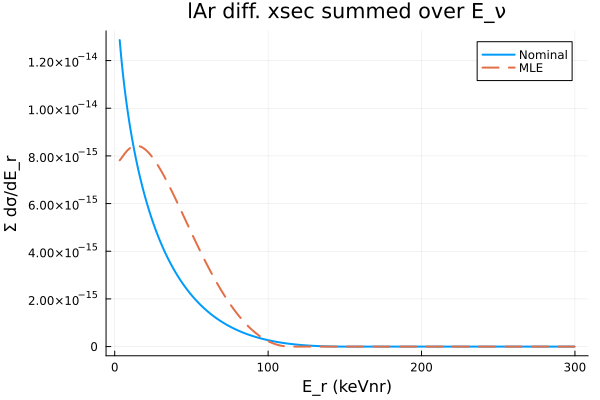

In [6]:
p_nom_lar = Newtrinos.get_params(coherent_lAr_cut)
p_mle_lar = bestfit_cut[3]

diff_xsec_nom = coherent_lAr_cut.physics.cevns_xsec.diff_xsec(p_nom_lar)[:Rn_Ar]
diff_xsec_mle = coherent_lAr_cut.physics.cevns_xsec.diff_xsec(p_mle_lar)[:Rn_Ar]

diff_xsec_nom_er = vec(sum(diff_xsec_nom, dims=2))
diff_xsec_mle_er = vec(sum(diff_xsec_mle, dims=2))

er_centers_keVnr = coherent_lAr_cut.assets.er_centers

Plots.plot(
    er_centers_keVnr,
    diff_xsec_nom_er;
    label="Nominal",
    lw=2,
    xlabel="E_r (keVnr)",
    ylabel="Σ dσ/dE_r",
    title="lAr diff. xsec summed over E_ν"
 )
Plots.plot!(
    er_centers_keVnr,
    diff_xsec_mle_er;
    label="MLE",
    lw=2,
    linestyle=:dash
 )